#Read The Data

In [154]:
import pandas as pd
import json
import os
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [155]:
with zipfile.ZipFile('/content/student_edu_info.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
print("student_edu_info.zip unzipped successfully.")

student_edu_info.zip unzipped successfully.


In [156]:
os.remove("/content/student_edu_info.zip")

convert json to Dataframe

In [157]:
with open("/content/student_edu_info/grades.json") as f :
  grades = json.load(f)
  grades = pd.json_normalize(
      grades,
      record_path=['grades'],
      meta=['student_id']
  )

In [158]:
assignment_submission = pd.read_csv("/content/student_edu_info/assignment_submissions.csv")
concept_performance = pd.read_csv("/content/student_edu_info/concepts_performance.csv")
courses = pd.read_csv("/content/student_edu_info/courses.csv")

groups = pd.read_csv("/content/student_edu_info/groups.csv")

In [159]:
students = pd.read_csv("/content/student_edu_info/students.csv")

In [160]:
engagement_events = pd.read_csv("/content/student_edu_info/engagement_events.csv")


In [161]:
xls = pd.ExcelFile("/content/student_edu_info/attendance.xlsx")
sheet_names = xls.sheet_names

all_sheets_df = []
for sheet_name in sheet_names:
    df = pd.read_excel(xls, sheet_name=sheet_name)
    if 'datetime' in df.columns:
      df['session_datetime'] = df['datetime']
      df.drop(columns=['datetime'], inplace=True)
    all_sheets_df.append(df)

attendance = pd.concat(all_sheets_df, ignore_index=True)

print("Attendance DataFrame (after reading all sheets):")
display(attendance.head())
print(f"Total rows: {len(attendance)}")

Attendance DataFrame (after reading all sheets):


,record_id,student_id,group_id,session_type,session_datetime,status
0,AT000001,S0005,G01,session,2025-12-04 16:00:00,attended
1,AT000002,S0009,G01,session,2025-12-04 16:00:00,attended
2,AT000003,S0014,G01,session,2025-12-04 16:00:00,attended
3,AT000004,S0016,G01,session,2025-12-04 16:00:00,attended
4,AT000005,S0021,G01,session,2025-12-04 16:00:00,attended


Total rows: 13010


#EDA for students

In [162]:
print("Students DataFrame - Head:")
display(students.head())



Students DataFrame - Head:


,student_id,full_name,age,gender,city,email,group_id,enrollment_date
0,S0001,Hana Gamal,27,Male,Mansoura,hana.gamal@kayfa-student.io,G03,2025-12-14
1,S0002,Mona Abdelaziz,25,Female,Zagazig,mona.abdelaziz@kayfa-student.io,G06,2025-12-03
2,S0003,Menna Naguib,20,Male,Ismailia,menna.naguib@kayfa-student.io,G05,2025-12-17
3,S0004,Aya ElShafei,21,Male,Giza,aya.elshafei@kayfa-student.io,G02,2025-12-12
4,S0005,Habiba Mahmoud,24,Male,Giza,habiba.mahmoud@kayfa-student.io,G01,2025-12-14


In [163]:
print("\nStudents DataFrame - Info:")
students.info()



Students DataFrame - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   student_id       502 non-null    object
 1   full_name        498 non-null    object
 2   age              502 non-null    int64 
 3   gender           502 non-null    object
 4   city             502 non-null    object
 5   email            502 non-null    object
 6   group_id         502 non-null    object
 7   enrollment_date  502 non-null    object
dtypes: int64(1), object(7)
memory usage: 31.5+ KB


In [164]:

print("\nStudents DataFrame - Descriptive Statistics:")
display(students.describe(include='all'))



Students DataFrame - Descriptive Statistics:


,student_id,full_name,age,gender,city,email,group_id,enrollment_date
count,502,498,502.000000,502,502,502,502,502
unique,500,402,NaN,10,10,405,12,20
top,S0074,Dina Zaki,NaN,Female,Zagazig,dina.zaki@kayfa-student.io,G04,2025-12-03
freq,2,5,NaN,260,60,5,65,32
mean,NaN,NaN,21.750996,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,7.442645,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,-22.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,19.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,21.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,NaN


In [165]:

print("\nStudents DataFrame - Null Values:")
print(students.isnull().sum())


Students DataFrame - Null Values:
student_id         0
full_name          4
age                0
gender             0
city               0
email              0
group_id           0
enrollment_date    0
dtype: int64


We can get the student name from the email

In [166]:
def extract_full_name_from_email(email):
    if pd.isna(email):
        return None
    # Extract the part before '@'
    name_part = email.split('@')[0]
    # Replace '.' with space and capitalize each word
    full_name = ' '.join([name.capitalize() for name in name_part.split('.')])
    return full_name

# Apply the function to fill null 'full_name' values
students['full_name'] = students.apply(
    lambda row: extract_full_name_from_email(row['email']) if pd.isna(row['full_name']) else row['full_name'],
    axis=1
)

print("Students DataFrame after filling missing full names:")
display(students[students['full_name'].isnull()])
print(students.isnull().sum())

Students DataFrame after filling missing full names:


,student_id,full_name,age,gender,city,email,group_id,enrollment_date


student_id         0
full_name          0
age                0
gender             0
city               0
email              0
group_id           0
enrollment_date    0
dtype: int64


In [167]:
students.head()

,student_id,full_name,age,gender,city,email,group_id,enrollment_date
0,S0001,Hana Gamal,27,Male,Mansoura,hana.gamal@kayfa-student.io,G03,2025-12-14
1,S0002,Mona Abdelaziz,25,Female,Zagazig,mona.abdelaziz@kayfa-student.io,G06,2025-12-03
2,S0003,Menna Naguib,20,Male,Ismailia,menna.naguib@kayfa-student.io,G05,2025-12-17
3,S0004,Aya ElShafei,21,Male,Giza,aya.elshafei@kayfa-student.io,G02,2025-12-12
4,S0005,Habiba Mahmoud,24,Male,Giza,habiba.mahmoud@kayfa-student.io,G01,2025-12-14


In [168]:
import numpy as np

def standardize_email(row):
    email = str(row['email']) if pd.notna(row['email']) else ''
    full_name = row['full_name']

    # Generate the desired local part from full_name, in case it's needed
    desired_local_part = full_name.lower().replace(' ', '.')

    # If email is missing, malformed (no '@'), or has no local part before '@'
    if not email or '@' not in email or email.startswith('@'):
        return f"{desired_local_part}@kayfa-student.io"

    # If email has an '@', extract the existing local part
    current_local_part = email.split('@')[0]

    # If the current local part is empty (e.g., if original email was '@domain.com')
    if not current_local_part:
        return f"{desired_local_part}@kayfa-student.io"

    # If a local part exists, keep it but ensure the domain is 'kayfa-student.io'
    return f"{current_local_part}@kayfa-student.io"

# Apply the function to the 'email' column
students['email'] = students.apply(standardize_email, axis=1)

print("Students DataFrame after email standardization:")
display(students.head())
print("\nCheck for any remaining emails without '@kayfa-student.io' domain:")
display(students[~students['email'].str.contains('@kayfa-student.io')])

Students DataFrame after email standardization:


,student_id,full_name,age,gender,city,email,group_id,enrollment_date
0,S0001,Hana Gamal,27,Male,Mansoura,hana.gamal@kayfa-student.io,G03,2025-12-14
1,S0002,Mona Abdelaziz,25,Female,Zagazig,mona.abdelaziz@kayfa-student.io,G06,2025-12-03
2,S0003,Menna Naguib,20,Male,Ismailia,menna.naguib@kayfa-student.io,G05,2025-12-17
3,S0004,Aya ElShafei,21,Male,Giza,aya.elshafei@kayfa-student.io,G02,2025-12-12
4,S0005,Habiba Mahmoud,24,Male,Giza,habiba.mahmoud@kayfa-student.io,G01,2025-12-14



Check for any remaining emails without '@kayfa-student.io' domain:


,student_id,full_name,age,gender,city,email,group_id,enrollment_date


Gender Distribution

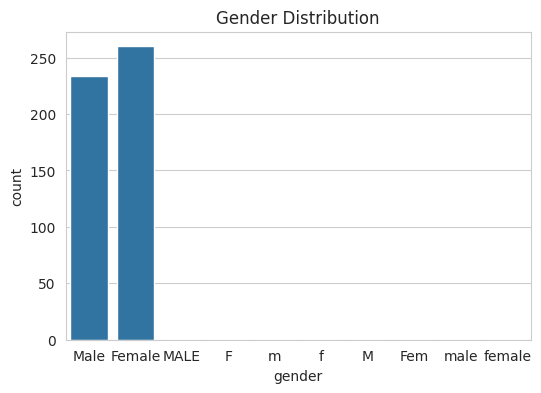

In [169]:
plt.figure(figsize=(6,4))
sns.countplot(data=students, x='gender')

plt.title('Gender Distribution')
plt.show()

okay , we can find there is a bad naming for the entities so we need to fix that

In [170]:
bad_name_maile = ["MALE" , "m","M","male"]
bad_name_female = ["F","f","Fem","female"]
students['gender']=students['gender'].replace(bad_name_maile,"Male")
students['gender']=students['gender'].replace(bad_name_female,"Female")

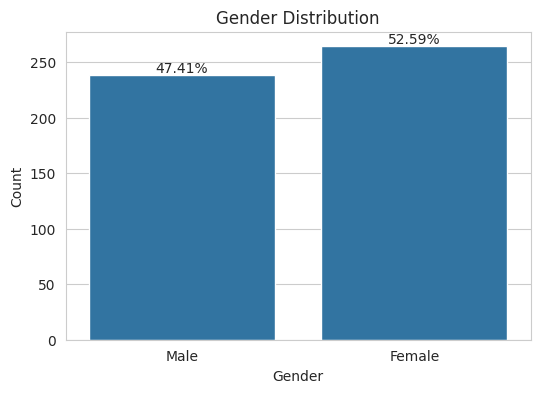

In [171]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=students, x='gender')
for p in ax.patches:
    percentage = 100 * p.get_height() / len(students)
    ax.annotate(f'{percentage:.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(
        0, 5), textcoords='offset points')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Distribution')
plt.show()

Age Distribution

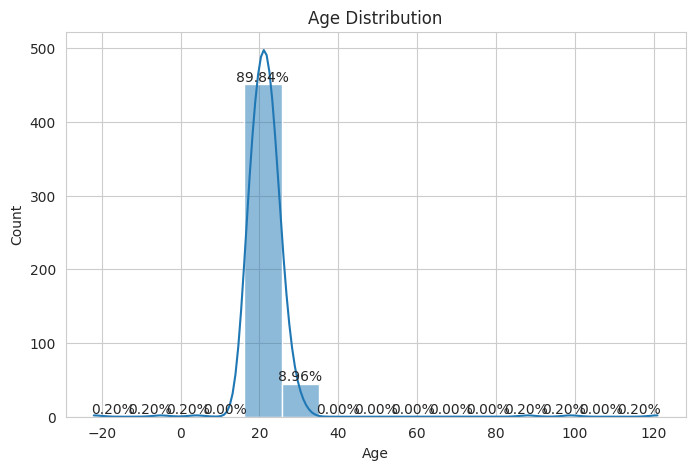

In [172]:
plt.figure(figsize=(8,5))
ax=sns.histplot(students['age'], bins=15, kde=True)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(students)
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

There is up normal values for the age , there is we can find from the hist plot that there is values are less that 20 and there is so negative values where it's not acceptable

In [173]:
students[students['age']<17]

,student_id,full_name,age,gender,city,email,group_id,enrollment_date
22,S0023,Tarek Gamal,4,Female,Mansoura,tarek.gamal@kayfa-student.io,G08,2025-12-19
208,S0209,Marwan Naguib,-22,Female,Giza,marwan.naguib@kayfa-student.io,G03,2025-12-12
452,S0453,Marwan ElBaz,-5,Male,Zagazig,marwan.elbaz@kayfa-student.io,G07,2025-12-10


first we have to find out if they are attending or not

In [174]:
# Get student_ids for students less than 17 years old
students_under_17_ids = students[students['age'] < 17]['student_id']

# Filter attendance DataFrame for these student_ids
attendance_under_17 = attendance[attendance['student_id'].isin(students_under_17_ids)]

display(attendance_under_17)

,record_id,student_id,group_id,session_type,session_datetime,status
447,AT002824,S0209,G03,session,2025-12-07 17:00:00,attended
502,AT002879,S0209,G03,session,2025-12-14 17:00:00,absent
557,AT002934,S0209,G03,session,2025-12-21 17:00:00,attended
612,AT002989,S0209,G03,quiz,2025-12-28 17:00:00,attended
1416,AT008631,S0453,G07,session,2025-12-03 21:00:00,attended
...,...,...,...,...,...,...
12502,AT011350,S0023,G08,exam,2026-05-02 17:00:00,False
12562,AT011410,S0023,G08,session,2026-05-09 17:00:00,True
12622,AT011470,S0023,G08,practical,2026-05-16 17:00:00,True
12682,AT011530,S0023,G08,session,2026-05-23 17:00:00,True


there for they are attending so we cannot remove them because the rows in attendance can be affected later

Mean age for students 17 and over: 21.93
Students DataFrame after updating ages:


/tmp/ipykernel_12605/2688378284.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '21.927855711422847' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  students.loc[students['age'] < 17, 'age'] = mean_age_over_17


,student_id,full_name,age,gender,city,email,group_id,enrollment_date
22,S0023,Tarek Gamal,21.927856,Female,Mansoura,tarek.gamal@kayfa-student.io,G08,2025-12-19
208,S0209,Marwan Naguib,21.927856,Female,Giza,marwan.naguib@kayfa-student.io,G03,2025-12-12
452,S0453,Marwan ElBaz,21.927856,Male,Zagazig,marwan.elbaz@kayfa-student.io,G07,2025-12-10


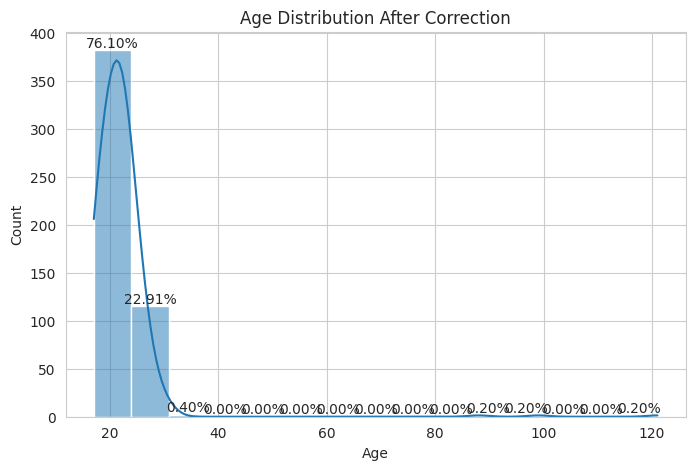

In [175]:
# Calculate the mean age for students aged 17 and above
mean_age_over_17 = students[students['age'] >= 17]['age'].mean()

# Replace ages less than 17 with the calculated mean age
students.loc[students['age'] < 17, 'age'] = mean_age_over_17

print(f"Mean age for students 17 and over: {mean_age_over_17:.2f}")
print("Students DataFrame after updating ages:")
display(students[students['age'] == mean_age_over_17])

plt.figure(figsize=(8,5))
ax=sns.histplot(students['age'], bins=15, kde=True)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(students)
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.title('Age Distribution After Correction')
plt.xlabel('Age')
plt.show()

we can find out also that there are some of them are higher that 30 , so we can do the same

Mean age for students 28 and over: 21.93
Students DataFrame after updating ages:


,student_id,full_name,age,gender,city,email,group_id,enrollment_date
22,S0023,Tarek Gamal,21.927856,Female,Mansoura,tarek.gamal@kayfa-student.io,G08,2025-12-19
50,S0051,Hana Fathy,21.927856,Female,Asyut,hana.fathy@kayfa-student.io,G05,2025-12-13
101,S0102,Farida ElShafei,21.927856,Female,Ismailia,farida.elshafei@kayfa-student.io,G02,2025-12-12
123,S0124,Dina Farouk,21.927856,Male,Port Said,dina.farouk@kayfa-student.io,G02,2025-12-17
182,S0183,Esraa Hassan,21.927856,Female,Port Said,esraa.hassan@kayfa-student.io,G02,2025-12-14
208,S0209,Marwan Naguib,21.927856,Female,Giza,marwan.naguib@kayfa-student.io,G03,2025-12-12
308,S0309,Abdelrahman Ibrahim,21.927856,Male,Giza,abdelrahman.ibrahim@kayfa-student.io,G06,2025-12-17
312,S0313,Sara Farouk,21.927856,Female,Mansoura,sara.farouk@kayfa-student.io,G01,2025-12-04
317,S0318,Abdelrahman Sultan,21.927856,Female,Mansoura,abdelrahman.sultan@kayfa-student.io,G03,2025-12-17
403,S0404,Hana Gamal,21.927856,Female,Fayoum,hana.gamal@kayfa-student.io,G09,2025-12-14


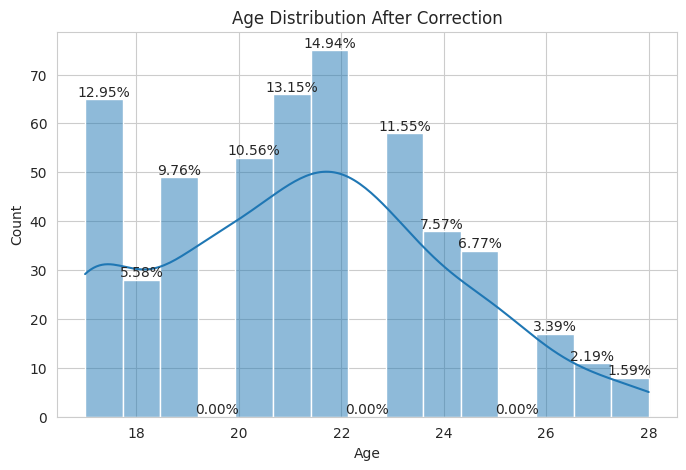

In [176]:
# Calculate the mean age for students aged 17 and above
mean_age_over_28 = students[students['age'] >= 17]['age'].mean()

# Replace ages less than 17 with the calculated mean age
students.loc[students['age'] > 28 , 'age'] = mean_age_over_28

print(f"Mean age for students 28 and over: {mean_age_over_28:.2f}")
print("Students DataFrame after updating ages:")
display(students[students['age'] == mean_age_over_28])

plt.figure(figsize=(8,5))
ax=sns.histplot(students['age'], bins=15, kde=True)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(students)
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.title('Age Distribution After Correction')
plt.xlabel('Age')
plt.show()

now age distribution is clear

Students per Group

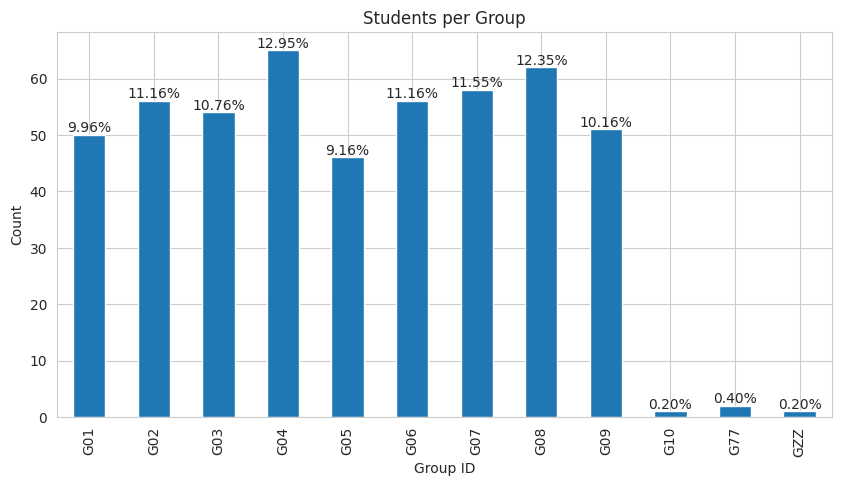

In [177]:
plt.figure(figsize=(10,5))

ax = students['group_id'].value_counts()\
                    .sort_index()\
                    .plot(kind='bar')
for p in ax.patches:
    percentage = 100 * p.get_height() / len(students)
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')

plt.title('Students per Group')
plt.xlabel('Group ID')
plt.ylabel('Count')
plt.show()

In [178]:
unusual_students=students[students['group_id'].isin( ["G10","G77","GZZ"])]['student_id']
correct_groups = attendance[attendance['student_id'].isin(unusual_students)].groupby('student_id')['group_id'].apply(lambda x: x.value_counts()).reset_index(name='count')
correct_groups

,student_id,level_1,count
0,S0014,G01,26
1,S0095,G01,26
2,S0323,G03,26
3,S0500,G10,26


therefor , they assigned in wrong groups on student name here

In [179]:
# Create a mapping series from correct_groups to get the new group_id (from level_1)
group_id_mapping = correct_groups.set_index('student_id')['level_1']

# Update the 'group_id' in the 'students' DataFrame using the mapping
students['group_id'] = students['student_id'].map(group_id_mapping).fillna(students['group_id'])

print("Students DataFrame after updating group_id for specific students:")
display(students[students['student_id'].isin(group_id_mapping.index)])

Students DataFrame after updating group_id for specific students:


,student_id,full_name,age,gender,city,email,group_id,enrollment_date
13,S0014,Ali Refaat,17.0,Male,Ismailia,ali.refaat@kayfa-student.io,G01,2025-12-18
94,S0095,Yasmin Fathy,22.0,Female,Zagazig,yasmin.fathy@kayfa-student.io,G01,2025-12-06
322,S0323,Aya Kamel,22.0,Female,Zagazig,aya.kamel@kayfa-student.io,G03,2025-12-18
499,S0500,Adel AbdelHamid,21.0,Male,Giza,adel.abdelhamid@kayfa-student.io,G10,2025-12-10


Students by City

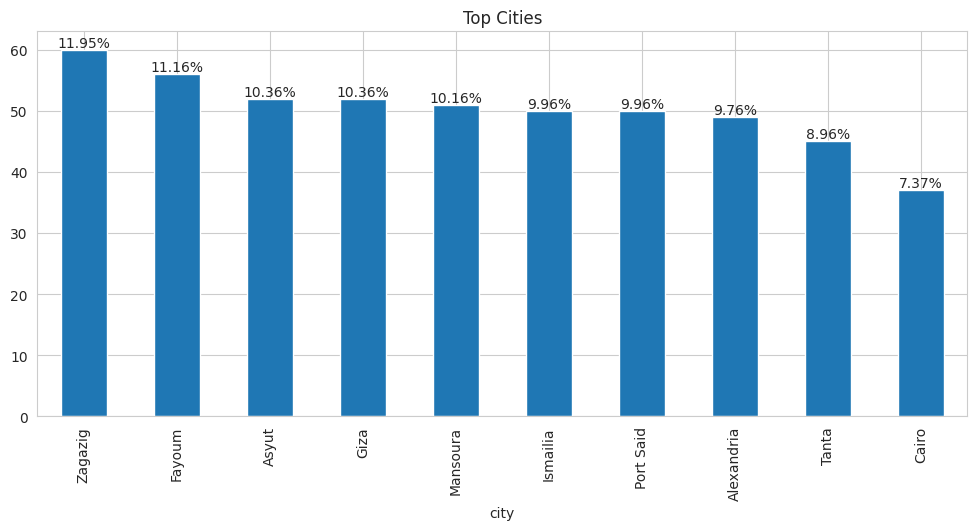

In [180]:
top_cities = students['city'].value_counts().head(15)
students['city'] = (students['city']).apply(lambda x: x.capitalize())
plt.figure(figsize=(12,5))
ax = top_cities.plot(kind='bar')
for p in ax.patches:
    percentage = 100 * p.get_height() / len(students)
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.title('Top Cities')
plt.show()

Group Composition

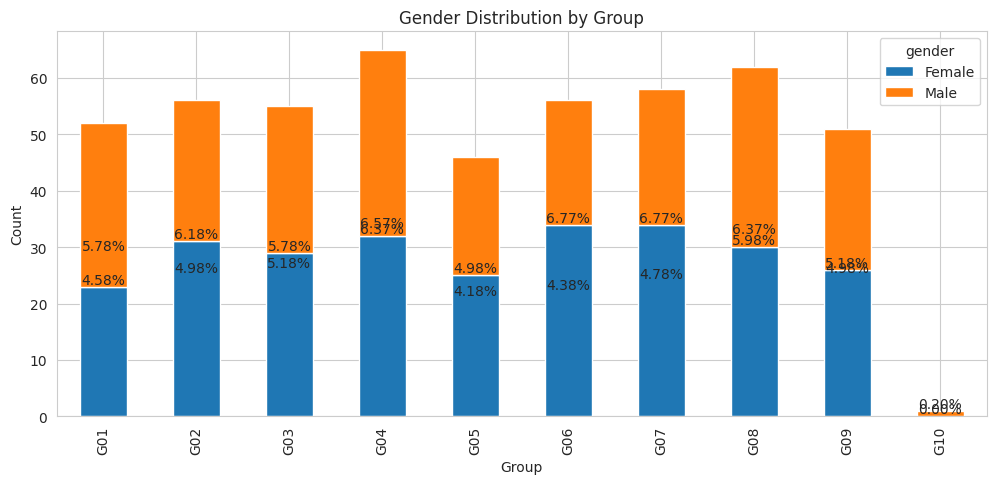

In [181]:
group_gender = pd.crosstab(
    students['group_id'],
    students['gender']
)

ax = group_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(12,5)
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(students)
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.xlabel('Group')
plt.ylabel('Count')
plt.title('Gender Distribution by Group')
plt.show()

Correlation with Performance

Text(0.5, 1.0, 'Age vs. Average Score')

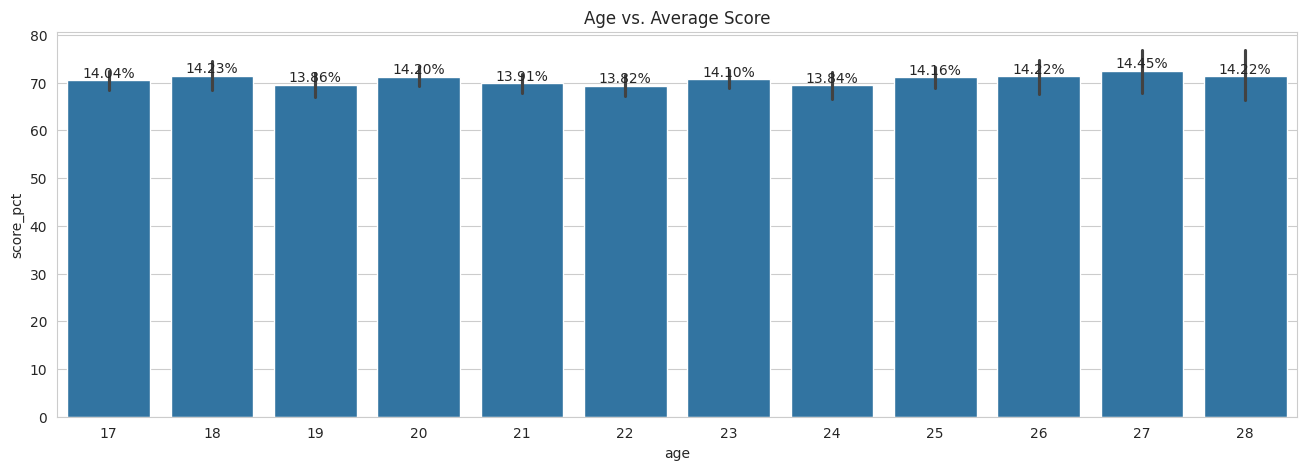

In [182]:
students['age'] = students['age'].astype(int)
student_scores = (
    concept_performance.groupby('student_id')['score_pct']
            .mean()
            .reset_index()
)

merged = students.merge(
    student_scores,
    on='student_id'

)
plt.figure(figsize=(16,5))
ax = sns.barplot(
    data=merged,
    x='age',
    y='score_pct'
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(merged)
    ax.annotate(f'{percentage:.2f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.title('Age vs. Average Score')

#grades EDA

In [183]:
print("Grades DataFrame - Head:")
grades.head()


Grades DataFrame - Head:


,grade_id,assessment_id,assessment_title,type,score,max_score,date,student_id
0,GR00001,C002-QZ,Quiz 1,quiz,-10.0,100,2025-12-27,S0001
1,GR00002,C002-QZ,Quiz 2,quiz,69.1,100,2026-01-10,S0001
2,GR00003,C002-QZ,Quiz 3,quiz,84.6,100,2026-01-24,S0001
3,GR00004,C002-QZ,Quiz 4,quiz,88.2,100,2026-02-07,S0001
4,GR00005,C002-AS,Assignment 1,assignment,67.4,100,2026-02-21,S0001


In [184]:
print("\nGrades DataFrame - Info:")
grades.info()



Grades DataFrame - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5502 entries, 0 to 5501
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   grade_id          5502 non-null   object 
 1   assessment_id     5502 non-null   object 
 2   assessment_title  5502 non-null   object 
 3   type              5502 non-null   object 
 4   score             5500 non-null   float64
 5   max_score         5502 non-null   int64  
 6   date              5502 non-null   object 
 7   student_id        5502 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 344.0+ KB


In [185]:
print("\nGrades DataFrame - Descriptive Statistics:")
grades.describe()



Grades DataFrame - Descriptive Statistics:


,score,max_score
count,5500.000000,5502.000000
mean,70.506200,99.983642
std,12.590239,1.213339
min,-10.000000,10.000000
25%,62.375000,100.000000
50%,70.700000,100.000000
75%,79.300000,100.000000
max,187.000000,100.000000


In [186]:
print("\nGrades DataFrame - Null Values:")
print(grades.isnull().sum())


Grades DataFrame - Null Values:
grade_id            0
assessment_id       0
assessment_title    0
type                0
score               2
max_score           0
date                0
student_id          0
dtype: int64


In [187]:
grades[grades['score'].isnull()]

,grade_id,assessment_id,assessment_title,type,score,max_score,date,student_id
25,GR00026,C003-QZ,Quiz 4,quiz,NaN,100,2026-02-09,S0003
37,GR00038,C001-AS,Assignment 1,assignment,NaN,100,2026-02-20,S0004


First probklem , there is 2 grades are missing
so we can find out if they attended this day or not

In [188]:
student_id_WithNoScore = grades[grades['score'].isnull()]['student_id']
Date_WithNoScore = grades[grades['score'].isnull()]['date']

In [189]:
grades['date'] = pd.to_datetime(grades['date'])
attendance['session_datetime'] = pd.to_datetime(attendance['session_datetime'])

# Re-extract Date_WithNoScore after ensuring grades['date'] is datetime
Date_WithNoScore = grades[grades['score'].isnull()]['date']

student_id_WithNoScore_list = student_id_WithNoScore.tolist()
date_WithNoScore_list = Date_WithNoScore.dt.date.tolist()

# Filter attendance where student_id is in student_id_WithNoScore and the date part of session_datetime is in Date_WithNoScore
missing_grade_attendance = attendance[
    (attendance['student_id'].isin(student_id_WithNoScore_list)) &
    (attendance['session_datetime'].dt.date.isin(date_WithNoScore_list))
]
display(missing_grade_attendance)

,record_id,student_id,group_id,session_type,session_datetime,status


so , we can find that they didn't attend in this dates , so we can search on assignment submission

In [190]:
assignment_submission['submitted_at'] = pd.to_datetime(assignment_submission['submitted_at'])
assignment_submission[
    (assignment_submission['student_id'].isin(student_id_WithNoScore_list)) &
    (assignment_submission['assessment_id'].isin(grades[grades['score'].isnull()]['assessment_id'].tolist()))
]

,submission_id,student_id,course_id,assessment_id,deadline,submitted_at,is_late,time_spent_minutes,attempts
9,SUB00010,S0004,C001,C001-AS,2026-02-20T23:59,NaT,False,105,1
10,SUB00011,S0004,C001,C001-AS,2026-03-06T23:59,2026-03-06 02:44:00,False,110,1
11,SUB00012,S0004,C001,C001-AS,2026-03-20T23:59,2026-03-20 07:26:00,False,150,2


so we can find that we have to drop these rows that the assignment had been submitted but it assigned three timess with different deadline and each time

In [191]:
grades['score'] = grades['score'].fillna(0)

In [192]:
duplications = grades['grade_id'].duplicated(keep=False)
grades[duplications]

,grade_id,assessment_id,assessment_title,type,score,max_score,date,student_id


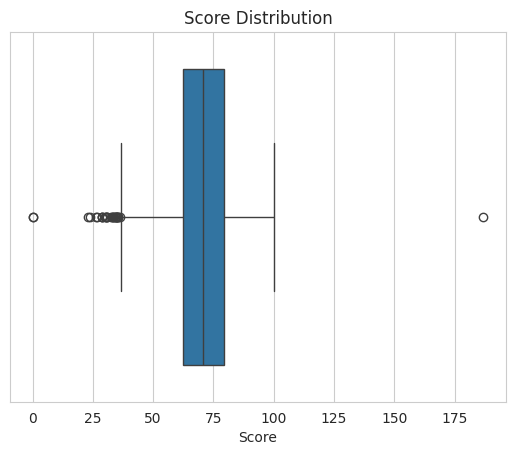

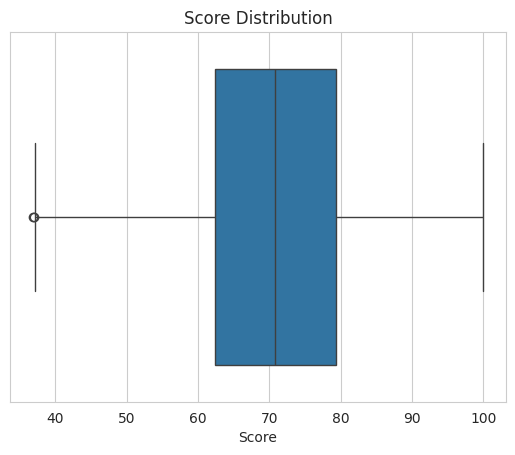

In [193]:
#remove outliers
grades_cleaned = grades[grades['score'] >= 0].copy()
sns.boxplot(x=grades_cleaned['score'])
plt.title('Score Distribution')
plt.xlabel('Score')
plt.show()
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df
grades = remove_outliers_iqr(grades_cleaned, 'score')
sns.boxplot(x=grades['score'])
plt.title('Score Distribution')
plt.xlabel('Score')
plt.show()

#EDA for Assignment submission

In [194]:
print("Assignment Submission DataFrame - Head:")
assignment_submission.head()

Assignment Submission DataFrame - Head:


,submission_id,student_id,course_id,assessment_id,deadline,submitted_at,is_late,time_spent_minutes,attempts
0,SUB00001,S0001,C002,C002-AS,2026-02-21T23:59,2026-02-21 18:59:00,True,176,1
1,SUB00002,S0001,C002,C002-AS,2026-03-07T23:59,2026-03-07 12:46:00,False,137,2
2,SUB00003,S0001,C002,C002-AS,2026-03-21T23:59,2026-03-21 15:45:00,False,44,1
3,SUB00004,S0002,C004,C004-AS,2026-02-15T23:59,2026-02-15 16:43:00,False,73,2
4,SUB00005,S0002,C004,C004-AS,2026-03-02T23:59,2026-03-02 16:37:00,False,91,3


In [195]:
print("\nAssignment Submission DataFrame - Info:")
assignment_submission.info()


Assignment Submission DataFrame - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   submission_id       1504 non-null   object        
 1   student_id          1504 non-null   object        
 2   course_id           1504 non-null   object        
 3   assessment_id       1504 non-null   object        
 4   deadline            1504 non-null   object        
 5   submitted_at        1503 non-null   datetime64[ns]
 6   is_late             1504 non-null   bool          
 7   time_spent_minutes  1504 non-null   int64         
 8   attempts            1504 non-null   int64         
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 95.6+ KB


In [196]:
print("\nAssignment Submission DataFrame - Descriptive Statistics:")
assignment_submission.describe()


Assignment Submission DataFrame - Descriptive Statistics:


,submitted_at,time_spent_minutes,attempts
count,1503,1504.000000,1504.000000
mean,2026-03-06 02:37:19.960079872,120.005984,1.591090
min,2026-02-13 11:23:00,-40.000000,1.000000
25%,2026-02-22 12:59:30,92.000000,1.000000
50%,2026-03-06 05:43:00,119.000000,1.000000
75%,2026-03-18 08:36:30,148.000000,2.000000
max,2026-03-24 17:04:00,255.000000,3.000000
std,NaN,40.284872,0.788102


In [197]:
print("\nAssignment Submission DataFrame - Null Values:")
assignment_submission.isnull().sum()


Assignment Submission DataFrame - Null Values:


,0
submission_id,0
student_id,0
course_id,0
assessment_id,0
deadline,0
submitted_at,1
is_late,0
time_spent_minutes,0
attempts,0


In [198]:
assignment_submission.dropna(inplace=True)

In [199]:
duplicates = assignment_submission[
    assignment_submission['submission_id'].duplicated(keep=False)
]

duplicates.sort_values('submission_id')

,submission_id,student_id,course_id,assessment_id,deadline,submitted_at,is_late,time_spent_minutes,attempts
88,SUB00089,S0030,C006,C006-AS,2026-03-09T23:59,2026-03-09 23:27:00,False,170,1
1503,SUB00089,S0030,C006,C006-AS,2026-03-09T23:59,2026-03-09 23:27:00,False,170,1
488,SUB00489,S0163,C001,C001-AS,2026-03-19T23:59,2026-03-19 07:11:00,False,130,1
1502,SUB00489,S0163,C001,C001-AS,2026-03-19T23:59,2026-03-19 07:11:00,False,130,1
1240,SUB01241,S0414,C005,C005-AS,2026-03-01T23:59,2026-03-01 21:04:00,False,117,1
1501,SUB01241,S0414,C005,C005-AS,2026-03-01T23:59,2026-03-01 21:04:00,False,117,1


In [200]:
assignment_submission = assignment_submission.drop_duplicates(
    subset='submission_id',
    keep='first'
)

remove outlier

Original assignment_submission shape: (1500, 9)
Assignment_submission shape after removing negative time spent: (1499, 9)


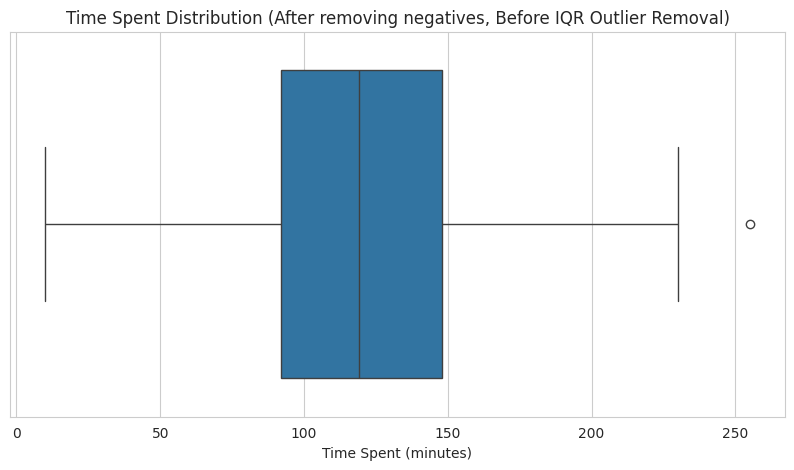

Assignment_submission shape after IQR outlier removal: (1499, 9)


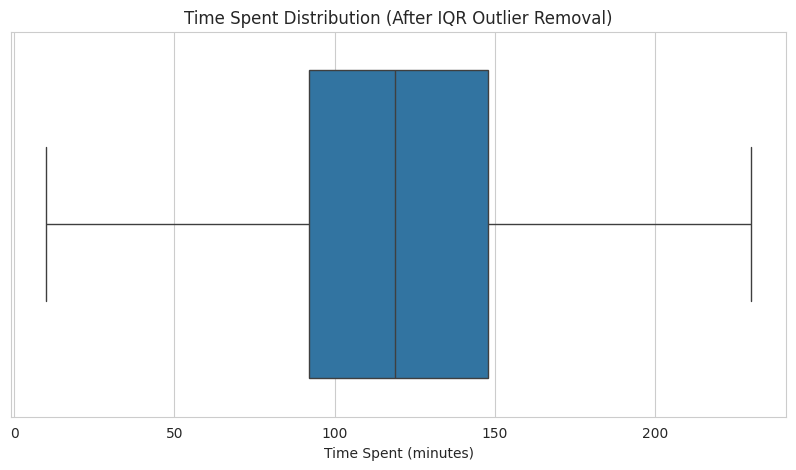

In [201]:
print(f"Original assignment_submission shape: {assignment_submission.shape}")

# Remove negative 'time_spent_minutes'
assignment_submission_cleaned = assignment_submission[assignment_submission['time_spent_minutes'] >= 0].copy()

print(f"Assignment_submission shape after removing negative time spent: {assignment_submission_cleaned.shape}")

# Boxplot before outlier removal (after removing negatives)
plt.figure(figsize=(10, 5))
sns.boxplot(x=assignment_submission_cleaned['time_spent_minutes'])
plt.title('Time Spent Distribution (After removing negatives, Before IQR Outlier Removal)')
plt.xlabel('Time Spent (minutes)')
plt.show()

# Function to remove outliers using the IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df

# Apply outlier removal to the 'time_spent_minutes' column
assignment_submission = remove_outliers_iqr(assignment_submission_cleaned, 'time_spent_minutes')

print(f"Assignment_submission shape after IQR outlier removal: {assignment_submission_cleaned.shape}")

# Boxplot after outlier removal
plt.figure(figsize=(10, 5))
sns.boxplot(x=assignment_submission['time_spent_minutes'])
plt.title('Time Spent Distribution (After IQR Outlier Removal)')
plt.xlabel('Time Spent (minutes)')
plt.show()


Late Submission Rate

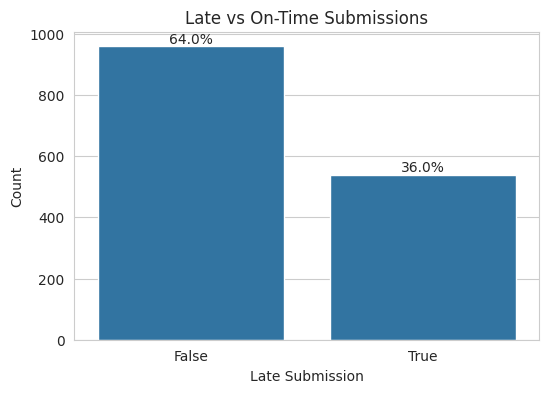

In [202]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=assignment_submission,
    x='is_late'
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(assignment_submission)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')

plt.xlabel('Late Submission')
plt.ylabel('Count')
plt.title("Late vs On-Time Submissions")
plt.show()

Time Spent Distribution

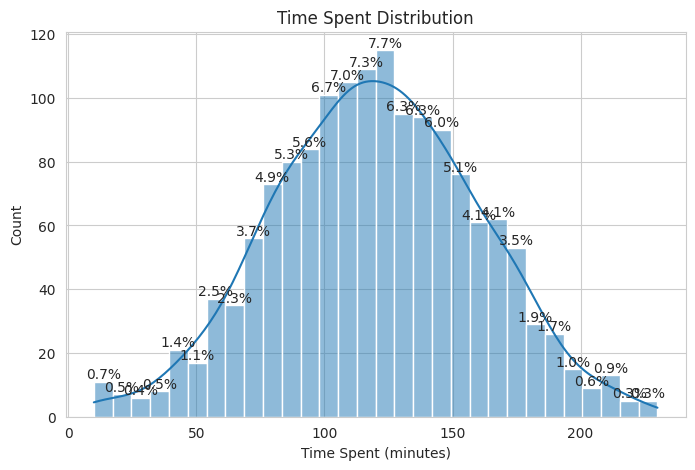

In [203]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    assignment_submission['time_spent_minutes'],
    bins=30,
    kde=True
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(assignment_submission)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')

plt.xlabel('Time Spent (minutes)')
plt.ylabel('Count')
plt.title("Time Spent Distribution")
plt.show()

Attempts Distribution

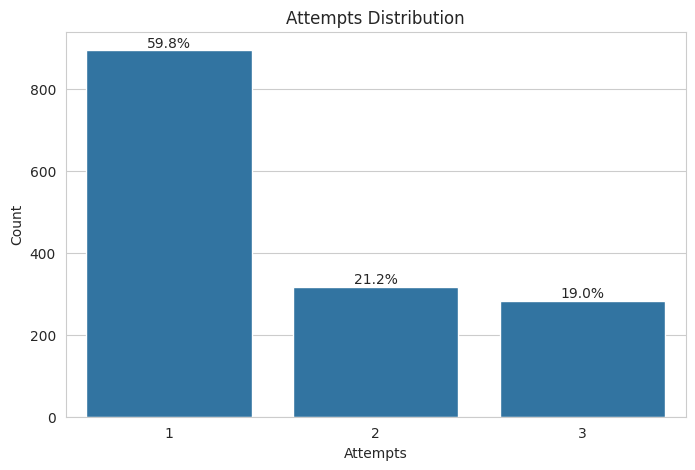

In [204]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=assignment_submission,
    x='attempts'
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(assignment_submission)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.xlabel('Attempts')
plt.ylabel('Count')

plt.title("Attempts Distribution")
plt.show()

Submission Activity Over Time

/tmp/ipykernel_12605/3510826069.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  assignment_submission['submitted_at'] = pd.to_datetime(


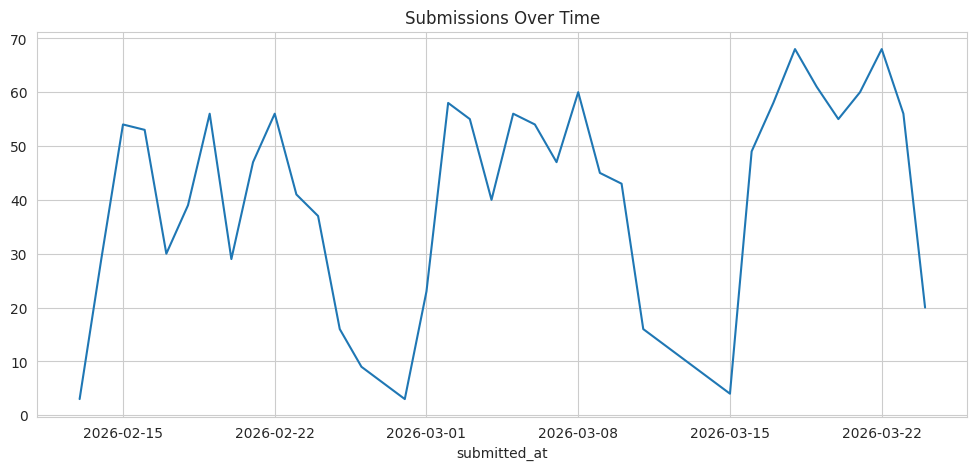

In [205]:
assignment_submission['submitted_at'] = pd.to_datetime(
    assignment_submission['submitted_at']
)

daily_assignment_submission = (
    assignment_submission.groupby(
        assignment_submission['submitted_at'].dt.date
    ).size()
)

daily_assignment_submission.plot(
    figsize=(12,5)
)

plt.title("Submissions Over Time")
plt.show()

Course Submission Volume

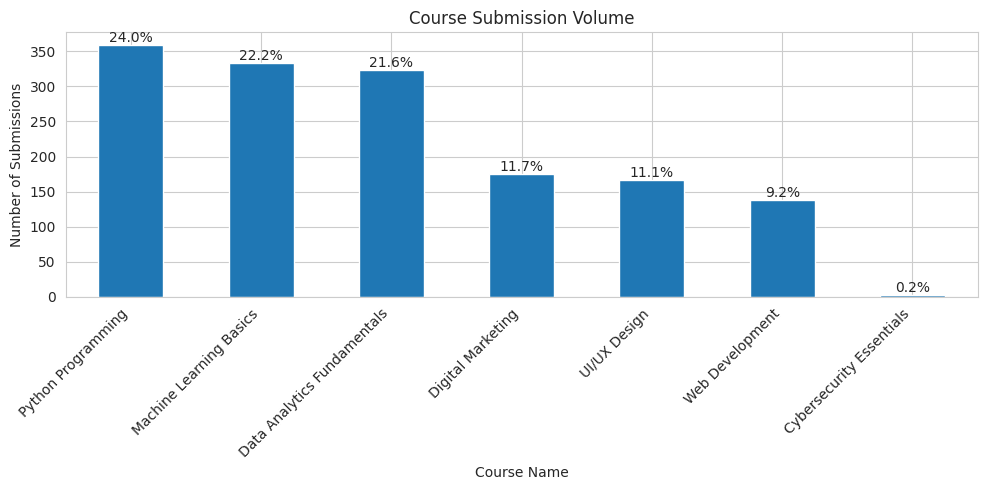

In [206]:
merged_submissions = assignment_submission.merge(courses[['course_id', 'course_name']], on='course_id', how='left')

course_subs = (
    merged_submissions['course_name']
    .value_counts()
)

ax = course_subs.plot(
    kind='bar',
    figsize=(10,5)
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(merged_submissions)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.title("Course Submission Volume")
plt.xlabel("Course Name")
plt.ylabel("Number of Submissions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Attempts by Course

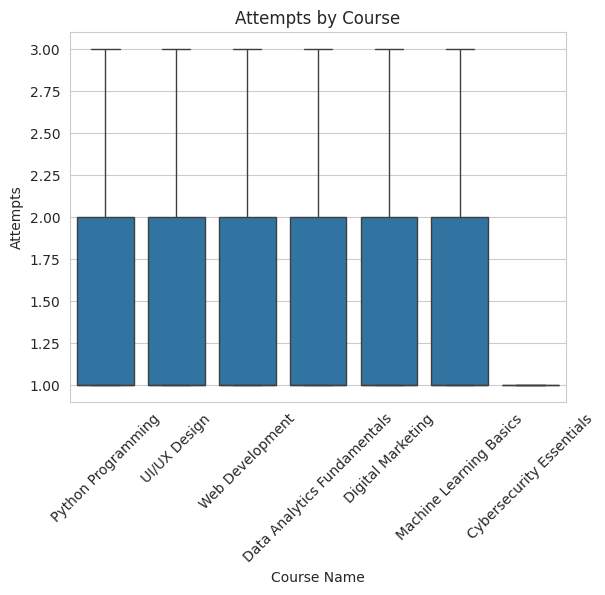

In [207]:
ax = sns.boxplot(
    data=merged_submissions,
    x='course_name',
    y='attempts'
)
plt.xlabel("Course Name")
plt.ylabel("Attempts")
plt.title("Attempts by Course")
plt.xticks(rotation=45)
plt.show()

#Attendance EDA

In [208]:
print("Attendance DataFrame - Head:")
display(attendance.head())



Attendance DataFrame - Head:


,record_id,student_id,group_id,session_type,session_datetime,status
0,AT000001,S0005,G01,session,2025-12-04 16:00:00,attended
1,AT000002,S0009,G01,session,2025-12-04 16:00:00,attended
2,AT000003,S0014,G01,session,2025-12-04 16:00:00,attended
3,AT000004,S0016,G01,session,2025-12-04 16:00:00,attended
4,AT000005,S0021,G01,session,2025-12-04 16:00:00,attended


In [209]:
print("\nAttendance DataFrame - Info:")
attendance.info()



Attendance DataFrame - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13010 entries, 0 to 13009
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   record_id         13010 non-null  object        
 1   student_id        13010 non-null  object        
 2   group_id          13010 non-null  object        
 3   session_type      13010 non-null  object        
 4   session_datetime  13010 non-null  datetime64[ns]
 5   status            13010 non-null  object        
dtypes: datetime64[ns](1), object(5)
memory usage: 610.0+ KB


In [210]:
merged_students_attendance = pd.merge(
    attendance,
    students,
    on=['student_id', 'group_id'],
    how='outer',
    indicator=True
)

print("\n--- Merged DataFrame Info ---")
merged_students_attendance.info()

print("\n--- Head of Merged DataFrame ---")
display(merged_students_attendance.head())

print("\n--- Merge Statistics ---")
print(merged_students_attendance['_merge'].value_counts())

# Identify records only in attendance or only in students
attendance_only = merged_students_attendance[
    merged_students_attendance['_merge'] == 'left_only'
]
students_only = merged_students_attendance[
    merged_students_attendance['_merge'] == 'right_only'
]

if not attendance_only.empty:
    print("\n--- Records only in Attendance (potential outliers/mismatches) ---")
    display(attendance_only[['student_id', 'group_id', 'session_datetime', 'status', 'full_name', '_merge']].head())
    # Corrected: Drop from 'attendance' using 'record_id'
    attendance = attendance[~attendance['record_id'].isin(attendance_only['record_id'])]
else:
    print("\nNo records found only in the attendance table.")

if not students_only.empty:
    print("\n--- Records only in Students (potential outliers/mismatches) ---")
    display(students_only[['student_id', 'group_id', 'session_datetime', 'status', 'full_name', '_merge']].head())
    # Corrected: Drop from 'students' using 'student_id'
    students = students[~students['student_id'].isin(students_only['student_id'])]
else:
    print("\nNo records found only in the students table.")


--- Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13062 entries, 0 to 13061
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   record_id         13062 non-null  object        
 1   student_id        13062 non-null  object        
 2   group_id          13062 non-null  object        
 3   session_type      13062 non-null  object        
 4   session_datetime  13062 non-null  datetime64[ns]
 5   status            13062 non-null  object        
 6   full_name         13060 non-null  object        
 7   age               13060 non-null  float64       
 8   gender            13060 non-null  object        
 9   city              13060 non-null  object        
 10  email             13060 non-null  object        
 11  enrollment_date   13060 non-null  object        
 12  _merge            13062 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(1)

,record_id,student_id,group_id,session_type,session_datetime,status,full_name,age,gender,city,email,enrollment_date,_merge
0,AT002809,S0001,G03,session,2025-12-07 17:00:00,attended,Hana Gamal,27.0,Male,Mansoura,hana.gamal@kayfa-student.io,2025-12-14,both
1,AT002864,S0001,G03,session,2025-12-14 17:00:00,attended,Hana Gamal,27.0,Male,Mansoura,hana.gamal@kayfa-student.io,2025-12-14,both
2,AT002919,S0001,G03,session,2025-12-21 17:00:00,attended,Hana Gamal,27.0,Male,Mansoura,hana.gamal@kayfa-student.io,2025-12-14,both
3,AT002974,S0001,G03,quiz,2025-12-28 17:00:00,attended,Hana Gamal,27.0,Male,Mansoura,hana.gamal@kayfa-student.io,2025-12-14,both
4,AT003029,S0001,G03,session,2026-01-04 17:00:00,Present,Hana Gamal,27.0,Male,Mansoura,hana.gamal@kayfa-student.io,2025-12-14,both



--- Merge Statistics ---
_merge
both          13060
left_only         2
right_only        0
Name: count, dtype: int64

--- Records only in Attendance (potential outliers/mismatches) ---


,student_id,group_id,session_datetime,status,full_name,_merge
4528,S0173,G06,2025-12-04 16:00:00,absent,NaN,left_only
13061,S9999,G01,2025-12-04 16:00:00,attended,NaN,left_only



No records found only in the students table.


In [211]:
duplicates = attendance[attendance['record_id'].duplicated(keep=False)]
duplicates.sort_values('record_id')
attendance = attendance.drop_duplicates(subset='record_id', keep='first')

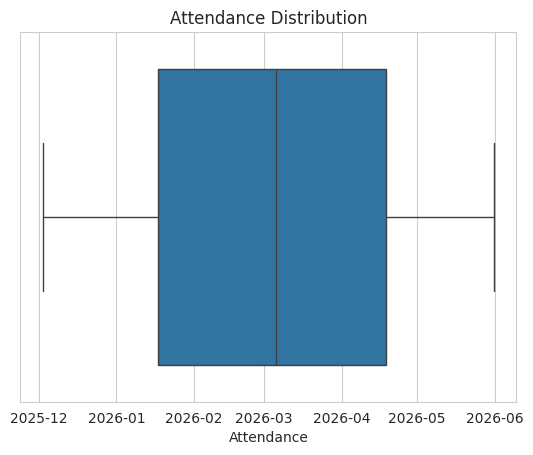

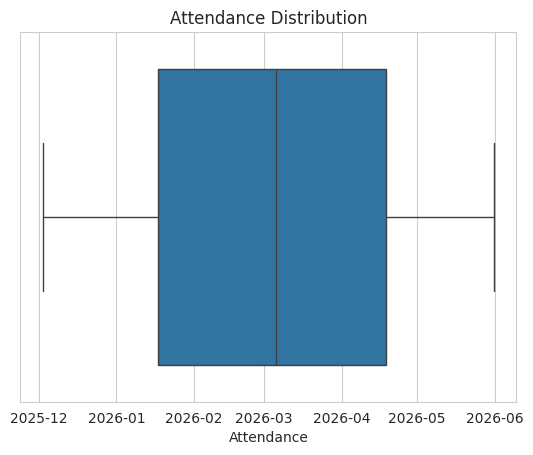

In [212]:
attendance_cleaned = attendance[attendance['status'] != 'Absent'].copy()
sns.boxplot(x=attendance_cleaned['session_datetime'])
plt.title('Attendance Distribution')
plt.xlabel('Attendance')
plt.show()
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df
attendance = remove_outliers_iqr(attendance_cleaned, 'session_datetime')
sns.boxplot(x=attendance['session_datetime'])
plt.title('Attendance Distribution')
plt.xlabel('Attendance')
plt.show()

Attendance distribution

In [213]:

print("\nAttendance DataFrame - Descriptive Statistics:")
display(attendance.describe(include='all'))



Attendance DataFrame - Descriptive Statistics:


,record_id,student_id,group_id,session_type,session_datetime,status
count,12513,12513,12513,12513,12513,12513.0
unique,12513,500,10,4,NaN,10.0
top,AT013000,S0310,G04,session,NaN,1.0
freq,1,27,1616,7735,NaN,3360.0
mean,NaN,NaN,NaN,NaN,2026-03-04 17:24:24.109326336,NaN
min,NaN,NaN,NaN,NaN,2025-12-02 16:00:00,NaN
25%,NaN,NaN,NaN,NaN,2026-01-17 17:00:00,NaN
50%,NaN,NaN,NaN,NaN,2026-03-05 19:00:00,NaN
75%,NaN,NaN,NaN,NaN,2026-04-18 17:00:00,NaN
max,NaN,NaN,NaN,NaN,2026-05-31 17:00:00,NaN


In [214]:

print("\nAttendance DataFrame - Null Values:")
print(attendance.isnull().sum())


Attendance DataFrame - Null Values:
record_id           0
student_id          0
group_id            0
session_type        0
session_datetime    0
status              0
dtype: int64


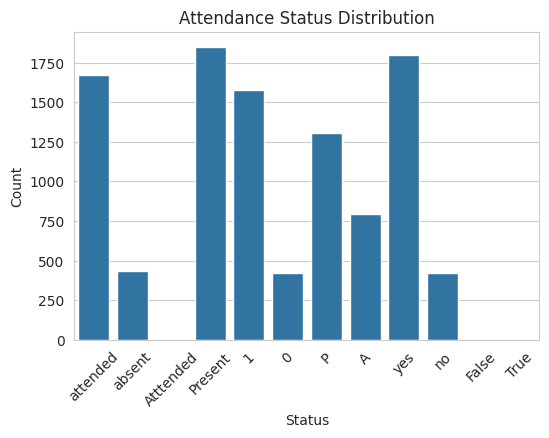

In [215]:
plt.figure(figsize=(6,4))
sns.countplot(data=attendance, x='status')

plt.title("Attendance Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [216]:
attendance['status'].value_counts()

,count
status,
1,3360
Present,1851
yes,1795
attended,1672
P,1308
0,876
A,794
absent,434
no,422


In [217]:
attendance['status']=attendance['status'].replace('Atttended','attended')
attended = ["Present","yes","P",1,"1"]
abesent=["A",0,"0","no"]
attendance['status'] = attendance['status'].replace(attended, 'attended')
attendance['status'] = attendance['status'].replace(abesent, 'absent')

In [218]:
attendance['status'].value_counts()

,count
status,
attended,9987
absent,2526


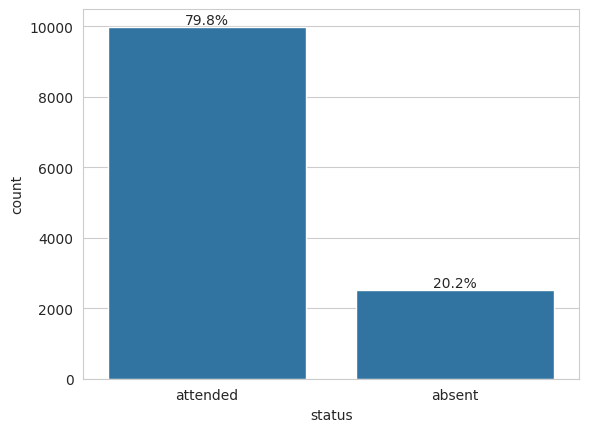

In [219]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.countplot(data=attendance, x='status')

total = len(attendance)

for p in ax.patches:
    percentage = 100 * p.get_height() / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')

plt.show()

Attendance rate by group

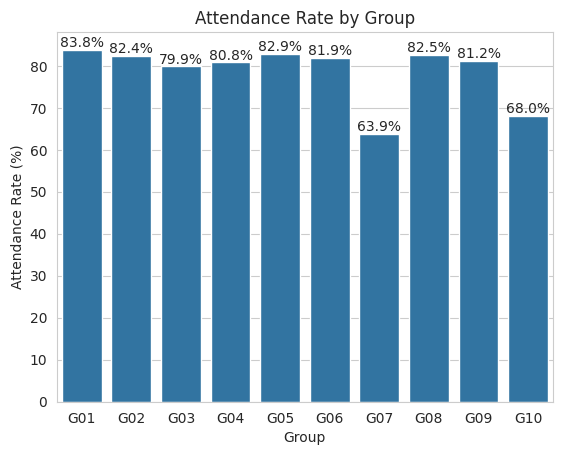

In [220]:
total = len(attendance)
group_attendance = (
    attendance.groupby('group_id')['status']
      .apply(lambda x: (x == 'attended').mean()*100)
      .reset_index(name='attendance_rate')
)
ax = sns.barplot(
    data=group_attendance,
    x='group_id',
    y='attendance_rate'
)

for p in ax.patches:
    percentage = p.get_height()
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')

plt.xlabel("Group")
plt.ylabel("Attendance Rate (%)")
plt.title("Attendance Rate by Group")
plt.show()

Attendance Rate by Session Type

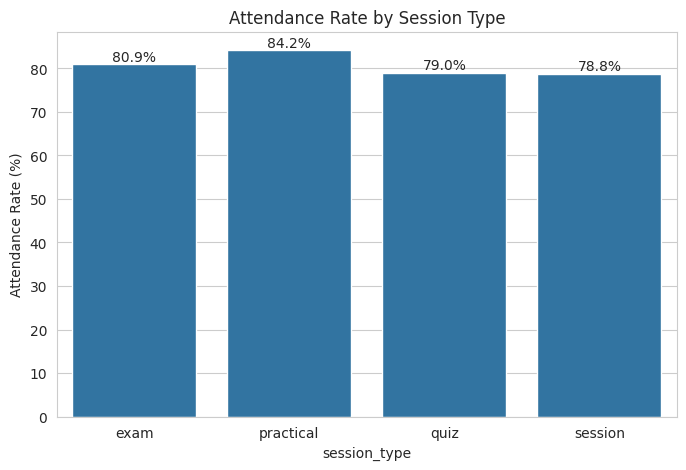

In [221]:
session_attendance = (
    attendance.groupby('session_type')['status']
      .apply(lambda x: (x == 'attended').mean()*100)
      .reset_index(name='attendance_rate')
)

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=session_attendance,
    x='session_type',
    y='attendance_rate'
)
for p in ax.patches:
    percentage = p.get_height()
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')
plt.title("Attendance Rate by Session Type")
plt.ylabel("Attendance Rate (%)")
plt.show()

Attendance Trend Over Time

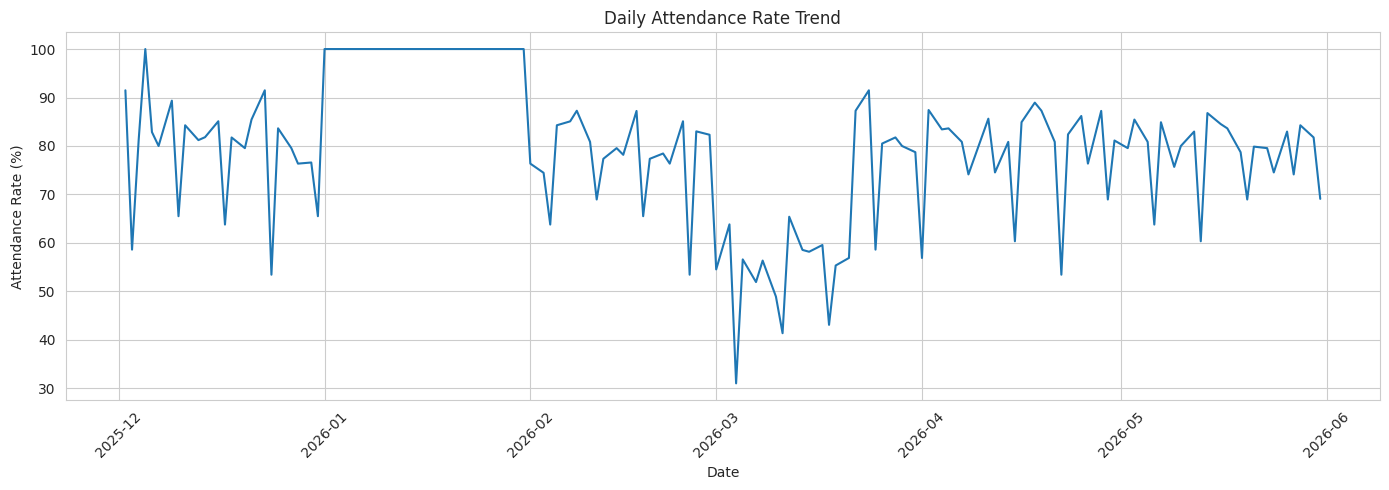

In [222]:
daily_attendance = (
    attendance.groupby(attendance['session_datetime'].dt.date)['status']
      .apply(lambda x: (x == 'attended').mean()*100)
      .reset_index(name='attendance_rate')
)

plt.figure(figsize=(14,5))
plt.plot(
    daily_attendance['session_datetime'],
    daily_attendance['attendance_rate']
)

plt.title("Daily Attendance Rate Trend")
plt.xlabel("Date")
plt.ylabel("Attendance Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Attendance by Day of Week

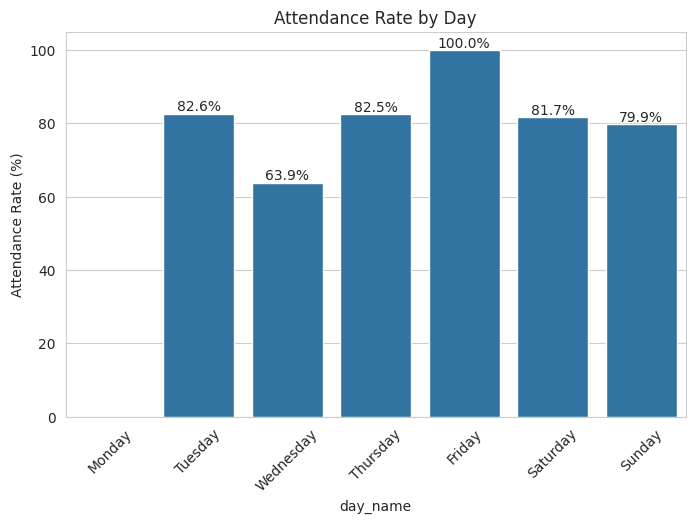

In [223]:
attendance['day_name'] = attendance['session_datetime'].dt.day_name()

day_attendance = (
    attendance.groupby('day_name')['status']
      .apply(lambda x: (x == 'attended').mean()*100)
      .reset_index(name='attendance_rate')
)

days_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

day_attendance['day_name'] = pd.Categorical(
    day_attendance['day_name'],
    categories=days_order,
    ordered=True
)

day_attendance = day_attendance.sort_values('day_name')

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=day_attendance,
    x='day_name',
    y='attendance_rate'
)
for p in ax.patches:
    percentage = p.get_height()
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center',
                va='bottom')

plt.title("Attendance Rate by Day")
plt.ylabel("Attendance Rate (%)")
plt.xticks(rotation=45)
plt.show()

Top 20 Students by Attendance

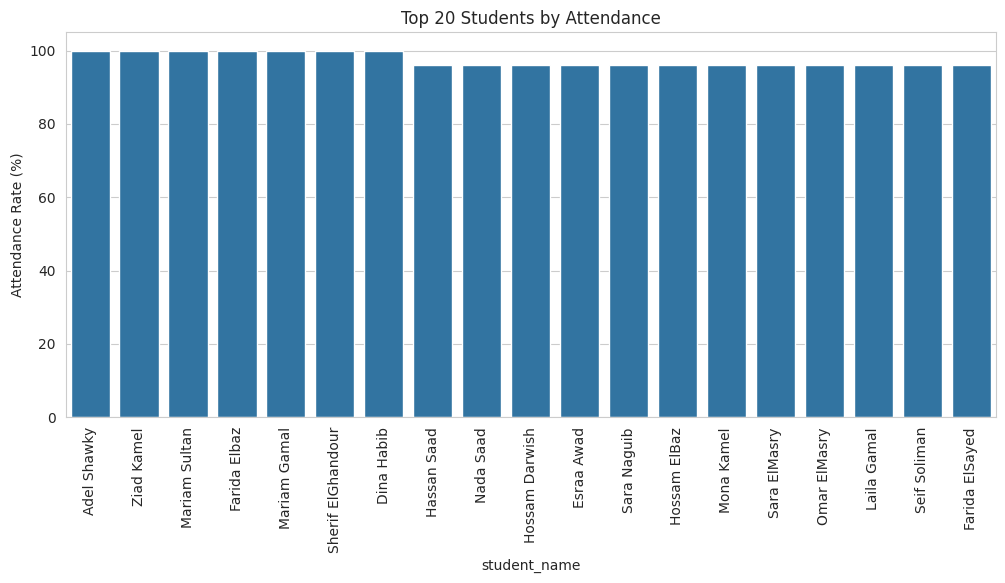

In [224]:
student_attendance = (
    attendance.groupby('student_id')['status']
      .apply(lambda x: (x == 'attended').mean()*100)
      .reset_index(name='attendance_rate')
      .sort_values('attendance_rate', ascending=False)
      .head(20)
)

# Ensure 'student_id' is unique in students DataFrame before mapping
students_unique = students.drop_duplicates(subset=['student_id'])

student_attendance['student_name'] = student_attendance['student_id'].map(
    students_unique.set_index('student_id')['full_name']
)
plt.figure(figsize=(12,5))
sns.barplot(
    data=student_attendance,
    x='student_name',
    y='attendance_rate'
)

plt.title("Top 20 Students by Attendance")
plt.ylabel("Attendance Rate (%)")
plt.xticks(rotation=90)
plt.show()

In [225]:
student_attendance

,student_id,attendance_rate,student_name
230,S0231,100.000000,Adel Shawky
21,S0022,100.000000,Ziad Kamel
436,S0437,100.000000,Mariam Sultan
134,S0135,100.000000,Farida Elbaz
445,S0446,100.000000,Mariam Gamal
110,S0111,100.000000,Sherif ElGhandour
358,S0359,100.000000,Dina Habib
250,S0251,96.153846,Hassan Saad
164,S0165,96.153846,Nada Saad
174,S0175,96.153846,Hossam Darwish


Distribution of Student Attendance Rates

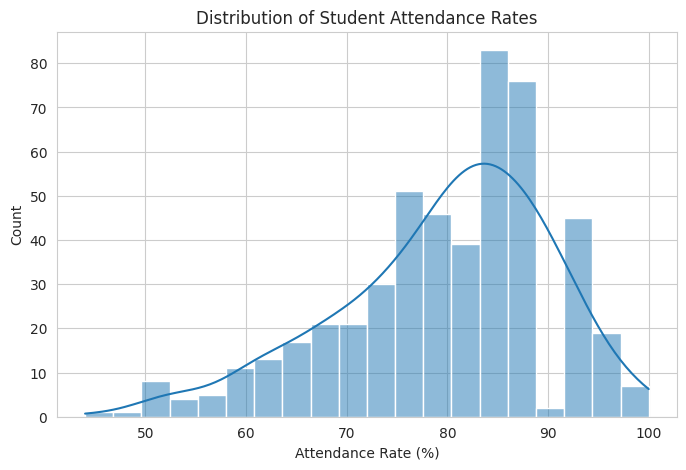

In [226]:
student_attendance = (
    attendance.groupby('student_id')['status']
      .apply(lambda x: (x == 'attended').mean()*100)
      .reset_index(name='attendance_rate')
)

plt.figure(figsize=(8,5))
sns.histplot(
    student_attendance['attendance_rate'],
    bins=20,
    kde=True
)

plt.title("Distribution of Student Attendance Rates")
plt.xlabel("Attendance Rate (%)")
plt.show()

Heatmap (Group × Session Type)

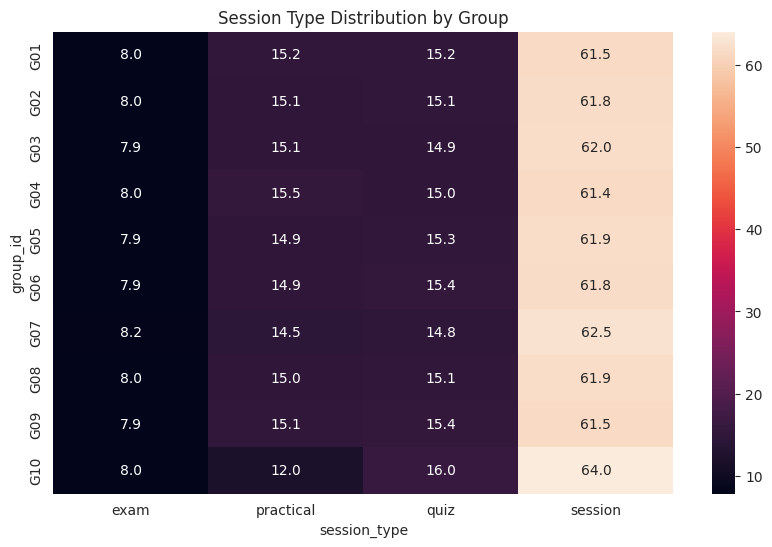

In [227]:
heatmap_data = pd.crosstab(
    attendance['group_id'],
    attendance['session_type'],
    normalize='index'
) * 100

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f'
)

plt.title("Session Type Distribution by Group")
plt.show()

#EDA Concept Performance

In [228]:
print("Concept Performance DataFrame - Head:")
display(concept_performance.head())


Concept Performance DataFrame - Head:


,record_id,student_id,course_id,assessment_id,question_no,concept_id,concept_name,score_pct,mastery_status,timestamp
0,CP000001,S0001,C002,C002-QZ,1,C002-K01,Variables & Types,80.0,passed,2025-12-27T23:06:24
1,CP000002,S0001,C002,C002-QZ,2,C002-K03,Functions,82.0,passed,2025-12-27T23:06:24
2,CP000003,S0001,C002,C002-QZ,3,C002-K06,File I/O,83.2,passed,2025-12-27T23:06:24
3,CP000004,S0001,C002,C002-QZ,4,C002-K05,Recursion,49.3,failed,2025-12-27T23:06:24
4,CP000005,S0001,C002,C002-QZ,1,C002-K02,Control Flow,59.4,failed,2026-01-10T23:06:24


In [229]:

print("\nConcept Performance DataFrame - Info:")
concept_performance.info()



Concept Performance DataFrame - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12008 entries, 0 to 12007
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       12008 non-null  object 
 1   student_id      12008 non-null  object 
 2   course_id       12008 non-null  object 
 3   assessment_id   12008 non-null  object 
 4   question_no     12008 non-null  int64  
 5   concept_id      12008 non-null  object 
 6   concept_name    12008 non-null  object 
 7   score_pct       12008 non-null  float64
 8   mastery_status  12008 non-null  object 
 9   timestamp       12008 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 938.3+ KB


In [230]:

print("\nConcept Performance DataFrame - Descriptive Statistics:")
display(concept_performance.describe(include='all'))



Concept Performance DataFrame - Descriptive Statistics:


,record_id,student_id,course_id,assessment_id,question_no,concept_id,concept_name,score_pct,mastery_status,timestamp
count,12008,12008,12008,12008,12008.00000,12008,12008,12008.000000,12008,12008
unique,12003,500,7,18,NaN,34,34,NaN,2,2992
top,CP008371,S0311,C002,C002-QZ,NaN,C006-K06,Clustering,NaN,passed,2026-01-05T21:54:11
freq,2,25,2881,1921,NaN,471,471,NaN,9134,9
mean,NaN,NaN,NaN,NaN,2.50000,NaN,NaN,70.381795,NaN,NaN
std,NaN,NaN,NaN,NaN,1.11823,NaN,NaN,15.233135,NaN,NaN
min,NaN,NaN,NaN,NaN,1.00000,NaN,NaN,-33.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.00000,NaN,NaN,60.500000,NaN,NaN
50%,NaN,NaN,NaN,NaN,2.50000,NaN,NaN,70.900000,NaN,NaN
75%,NaN,NaN,NaN,NaN,4.00000,NaN,NaN,81.200000,NaN,NaN


In [231]:

print("\nConcept Performance DataFrame - Null Values:")
print(concept_performance.isnull().sum())


Concept Performance DataFrame - Null Values:
record_id         0
student_id        0
course_id         0
assessment_id     0
question_no       0
concept_id        0
concept_name      0
score_pct         0
mastery_status    0
timestamp         0
dtype: int64


In [232]:
unusal_concpt_student = concept_performance[concept_performance['concept_name']=='Ã‚Â¤Ã¢â‚¬#@@ ??x??']['student_id']
unusal_concpt = concept_performance[concept_performance['concept_name']=='Ã‚Â¤Ã¢â‚¬#@@ ??x??']['course_id']
same_courese = courses[courses['course_id'].isin(unusal_concpt)]
# To access the 'modules' column from the first row of 'same_courese':
same_courese_modules = same_courese.loc[0, 'modules']
print(same_courese_modules)

["Spreadsheets & Tabular Data", "Descriptive Statistics", "Data Cleaning", "GroupBy & Aggregation", "Joins & Merges", "Data Visualization Basics"]


so now , we have modules where can search within it

In [233]:
import json

# Parse the string representation of the list into an actual list
parsed_modules = json.loads(same_courese_modules)

modules_in=concept_performance[
    concept_performance['course_id'].isin(unusal_concpt) &
    concept_performance['student_id'].isin(unusal_concpt_student) &
    concept_performance['concept_name'].isin(parsed_modules)
]['concept_name'].tolist()
modules_out = [ x for x in parsed_modules if x not in modules_in]
print(modules_in)
print(modules_out)

['Joins & Merges', 'Spreadsheets & Tabular Data', 'Data Cleaning', 'GroupBy & Aggregation', 'GroupBy & Aggregation', 'Descriptive Statistics', 'Spreadsheets & Tabular Data', 'Data Visualization Basics', 'Spreadsheets & Tabular Data', 'GroupBy & Aggregation', 'Data Visualization Basics', 'Descriptive Statistics', 'Joins & Merges', 'Data Visualization Basics', 'Spreadsheets & Tabular Data', 'Descriptive Statistics', 'Data Visualization Basics', 'Descriptive Statistics', 'Spreadsheets & Tabular Data', 'GroupBy & Aggregation', 'Data Visualization Basics', 'Descriptive Statistics', 'Spreadsheets & Tabular Data', 'GroupBy & Aggregation']
[]


so we can exclude this concept

In [234]:
concept_performance = concept_performance[concept_performance['concept_name']!='Ã‚Â¤Ã¢â‚¬#@@ ??x??']

In [235]:
duplicates = concept_performance[concept_performance['record_id'].duplicated(keep=False)]
duplicates.sort_values('record_id')
concept_performance = concept_performance.drop_duplicates(subset='record_id', keep='first')

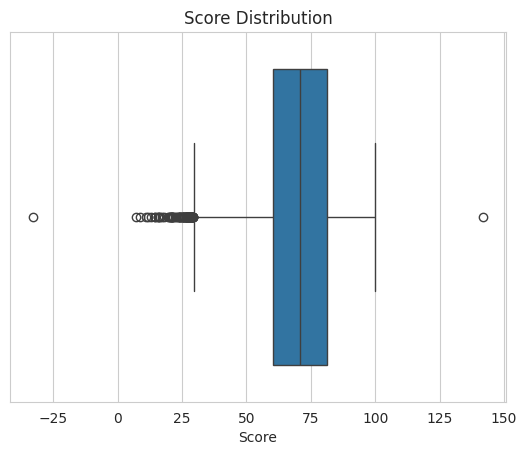

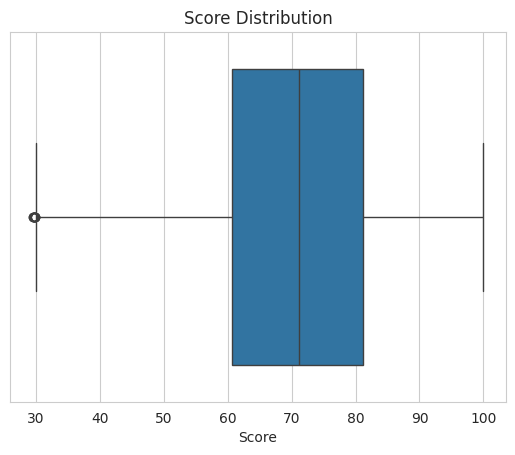

In [236]:
concept_performance_cleaned = concept_performance[concept_performance['score_pct'] != 0].copy()
sns.boxplot(x=concept_performance_cleaned['score_pct'])
plt.title('Score Distribution')
plt.xlabel('Score')
plt.show()
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df
concept_performance = remove_outliers_iqr(concept_performance_cleaned, 'score_pct')
sns.boxplot(x=concept_performance['score_pct'])
plt.title('Score Distribution')
plt.xlabel('Score')
plt.show()

Distribution of Scores

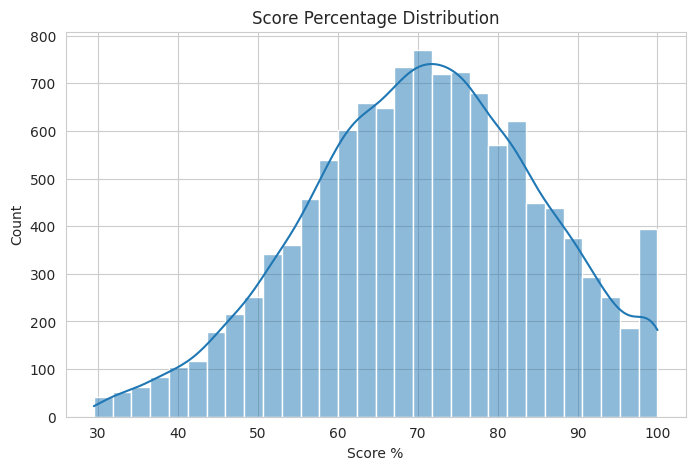

In [237]:
plt.figure(figsize=(8,5))
sns.histplot(concept_performance['score_pct'], bins=30, kde=True)

plt.title('Score Percentage Distribution')
plt.xlabel('Score %')
plt.show()

Mastery Status Distribution

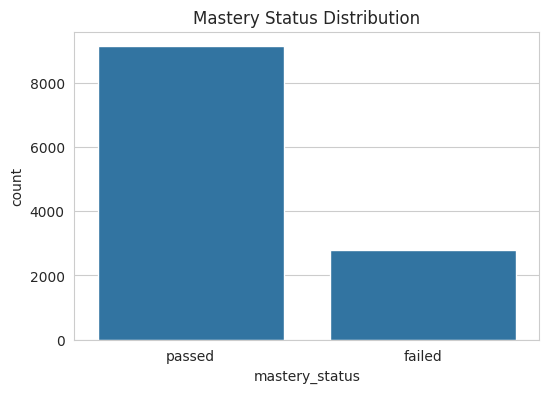

In [238]:
plt.figure(figsize=(6,4))
sns.countplot(data=concept_performance, x='mastery_status')

plt.title('Mastery Status Distribution')
plt.show()

Hardest Concepts

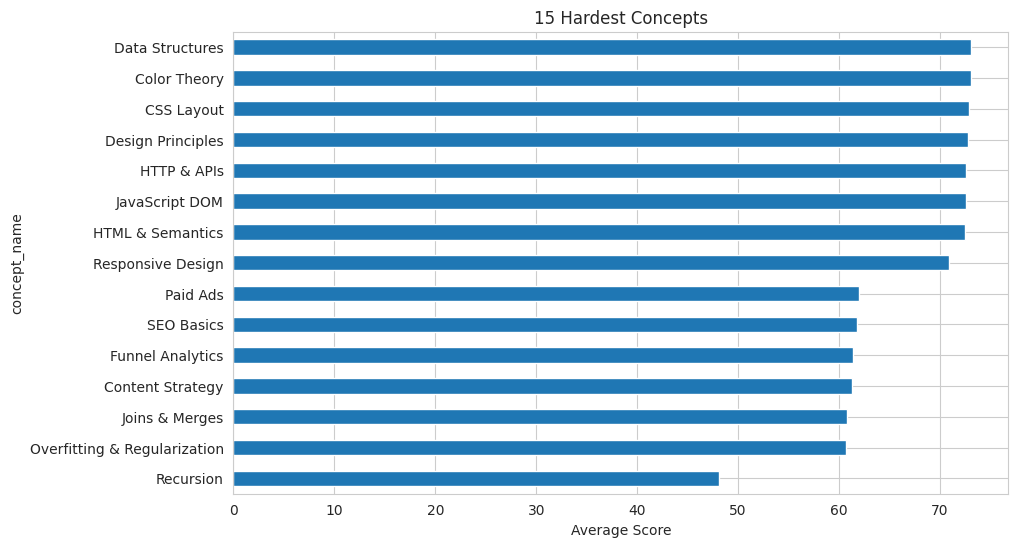

In [239]:
concept_scores = (
    concept_performance.groupby('concept_name')['score_pct']
      .mean()
      .sort_values()
      .head(15)
)

plt.figure(figsize=(10,6))
concept_scores.plot(kind='barh')

plt.title('15 Hardest Concepts')
plt.xlabel('Average Score')
plt.show()

Easiest Concepts

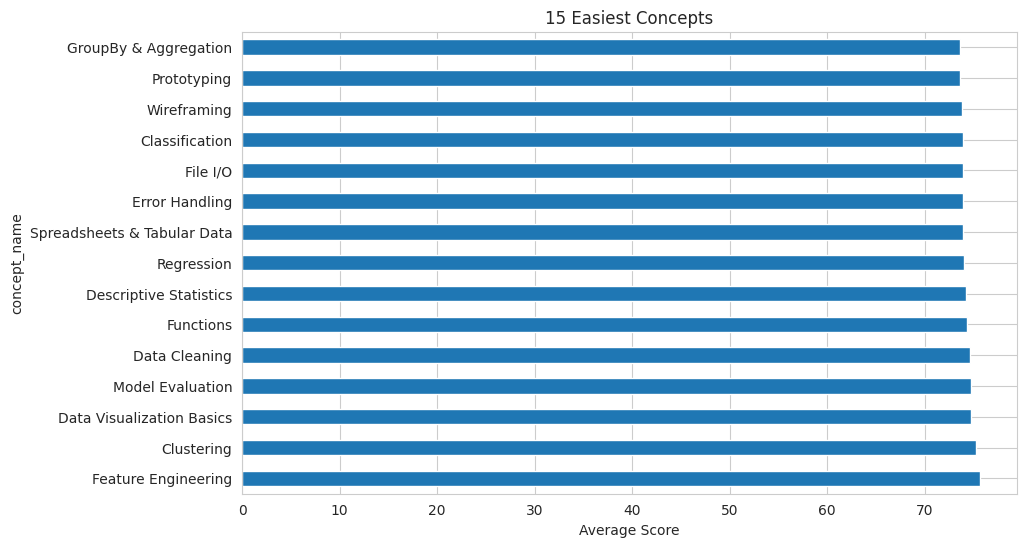

In [240]:
concept_scores = (
    concept_performance.groupby('concept_name')['score_pct']
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))
concept_scores.plot(kind='barh')

plt.title('15 Easiest Concepts')
plt.xlabel('Average Score')
plt.show()

In [241]:
concept_scores

,score_pct
concept_name,
Feature Engineering,75.690456
Clustering,75.276221
Data Visualization Basics,74.801794
Model Evaluation,74.790115
Data Cleaning,74.695476
Functions,74.340295
Descriptive Statistics,74.213115
Regression,74.068707
Spreadsheets & Tabular Data,73.967299


#EDA courses

In [242]:
print("Courses DataFrame - Head:")
display(courses.head())



Courses DataFrame - Head:


,course_id,course_name,category,difficulty_level,duration_weeks,short_description,modules,is_active
0,C001,Data Analytics Fundamentals,Analytics,Beginner,12,Data Analytics Fundamentals — hands-on analyti...,"[""Spreadsheets & Tabular Data"", ""Descriptive S...",True
1,C002,Python Programming,Programming,Beginner,14,Python Programming — hands-on programming trac...,"[""Variables & Types"", ""Control Flow"", ""Functio...",True
2,C003,Web Development,Programming,Intermediate,16,Web Development — hands-on programming track a...,"[""HTML & Semantics"", ""CSS Layout"", ""JavaScript...",True
3,C004,UI/UX Design,Design,Beginner,10,UI/UX Design — hands-on design track at Kayfa.,"[""Design Principles"", ""Wireframing"", ""Color Th...",True
4,C005,Digital Marketing,Business,Beginner,8,Digital Marketing — hands-on business track at...,"[""SEO Basics"", ""Content Strategy"", ""Paid Ads"",...",True


In [243]:
courses['modules'] = courses['modules'].apply(json.loads)

In [244]:
courses = courses.explode('modules')
print("Courses DataFrame expanded by modules - Head:")
display(courses.head())

Courses DataFrame expanded by modules - Head:


,course_id,course_name,category,difficulty_level,duration_weeks,short_description,modules,is_active
0,C001,Data Analytics Fundamentals,Analytics,Beginner,12,Data Analytics Fundamentals — hands-on analyti...,Spreadsheets & Tabular Data,True
0,C001,Data Analytics Fundamentals,Analytics,Beginner,12,Data Analytics Fundamentals — hands-on analyti...,Descriptive Statistics,True
0,C001,Data Analytics Fundamentals,Analytics,Beginner,12,Data Analytics Fundamentals — hands-on analyti...,Data Cleaning,True
0,C001,Data Analytics Fundamentals,Analytics,Beginner,12,Data Analytics Fundamentals — hands-on analyti...,GroupBy & Aggregation,True
0,C001,Data Analytics Fundamentals,Analytics,Beginner,12,Data Analytics Fundamentals — hands-on analyti...,Joins & Merges,True


In [245]:
courses.loc[0, 'short_description']

,short_description
0,Data Analytics Fundamentals — hands-on analyti...
0,Data Analytics Fundamentals — hands-on analyti...
0,Data Analytics Fundamentals — hands-on analyti...
0,Data Analytics Fundamentals — hands-on analyti...
0,Data Analytics Fundamentals — hands-on analyti...
0,Data Analytics Fundamentals — hands-on analyti...


In [246]:
print("\nCourses DataFrame - Info:")
courses.info()



Courses DataFrame - Info:
<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 0 to 6
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   course_id          38 non-null     object
 1   course_name        38 non-null     object
 2   category           38 non-null     object
 3   difficulty_level   38 non-null     object
 4   duration_weeks     38 non-null     int64 
 5   short_description  38 non-null     object
 6   modules            38 non-null     object
 7   is_active          38 non-null     bool  
dtypes: bool(1), int64(1), object(6)
memory usage: 3.5+ KB


In [247]:

print("\nCourses DataFrame - Descriptive Statistics:")
display(courses.describe(include='all'))



Courses DataFrame - Descriptive Statistics:


,course_id,course_name,category,difficulty_level,duration_weeks,short_description,modules,is_active
count,38,38,38,38,38.000000,38,38,38
unique,7,7,5,3,NaN,7,38,1
top,C002,Python Programming,Analytics,Beginner,NaN,Python Programming — hands-on programming trac...,Spreadsheets & Tabular Data,True
freq,7,7,12,22,NaN,7,1,38
mean,NaN,NaN,NaN,NaN,12.842105,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,2.656215,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,8.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,12.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,16.000000,NaN,NaN,NaN


In [248]:

print("\nCourses DataFrame - Null Values:")
print(courses.isnull().sum())


Courses DataFrame - Null Values:
course_id            0
course_name          0
category             0
difficulty_level     0
duration_weeks       0
short_description    0
modules              0
is_active            0
dtype: int64


In [249]:
duplicates = courses[courses['course_id'].duplicated(keep=False)]
duplicates.sort_values('course_id')
courses = courses.drop_duplicates(subset='course_id', keep='first')

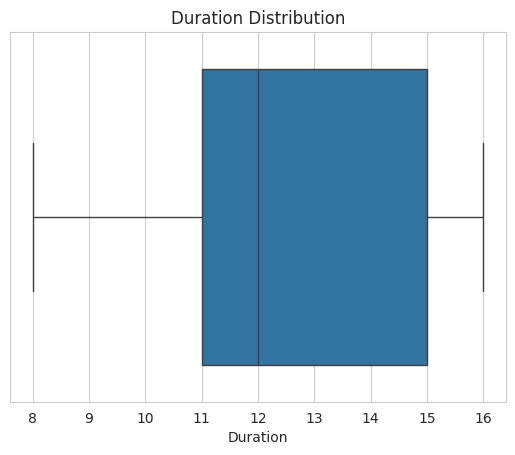

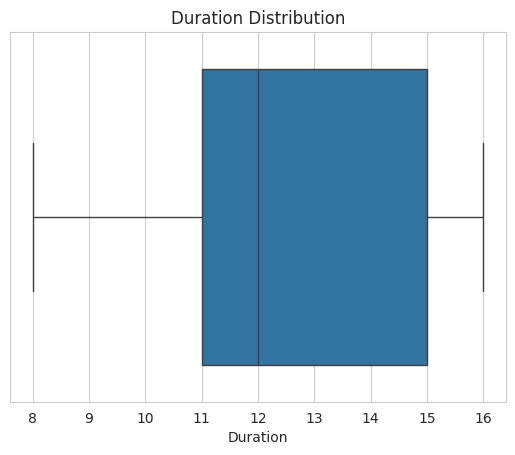

In [250]:
courese_cleaned = courses[courses['duration_weeks'] != 0].copy()
sns.boxplot(x=courese_cleaned['duration_weeks'])
plt.title('Duration Distribution')
plt.xlabel('Duration')
plt.show()
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df
courses = remove_outliers_iqr(courese_cleaned, 'duration_weeks')
sns.boxplot(x=courses['duration_weeks'])
plt.title('Duration Distribution')
plt.xlabel('Duration')
plt.show()


Course Categories Distribution

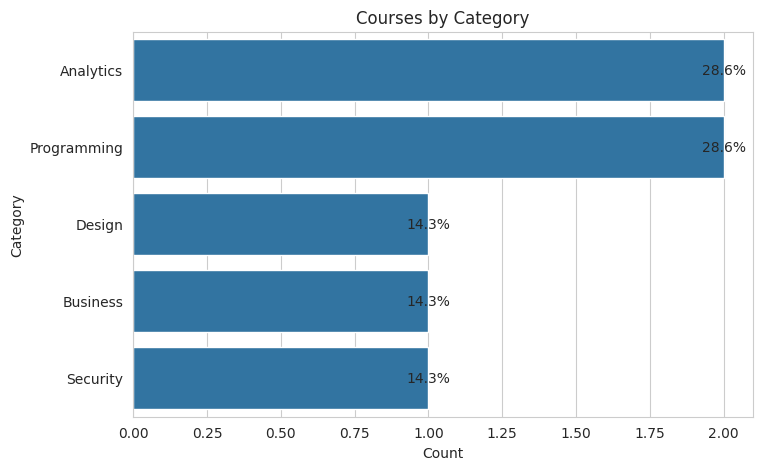

In [251]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=courses,
    y='category',
    order=courses['category'].value_counts().index
)
for p in ax.patches:
    percentage = 100 * p.get_width() / len(courses)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(), p.get_y() + p.get_height() / 2),
                ha='center',
                va='center')
plt.xlabel("Count")
plt.ylabel("Category")
plt.title('Courses by Category')
plt.show()

Difficulty Level Distribution

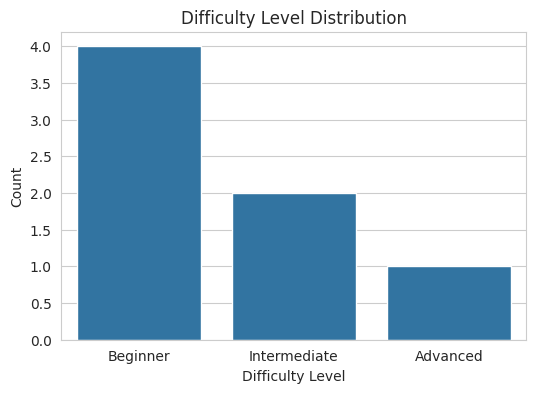

In [252]:
ax = plt.figure(figsize=(6,4))
sns.countplot(
    data=courses,
    x='difficulty_level'
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(courses)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Difficulty Level")
plt.ylabel("Count")
plt.title('Difficulty Level Distribution')
plt.show()

Course Duration Distribution

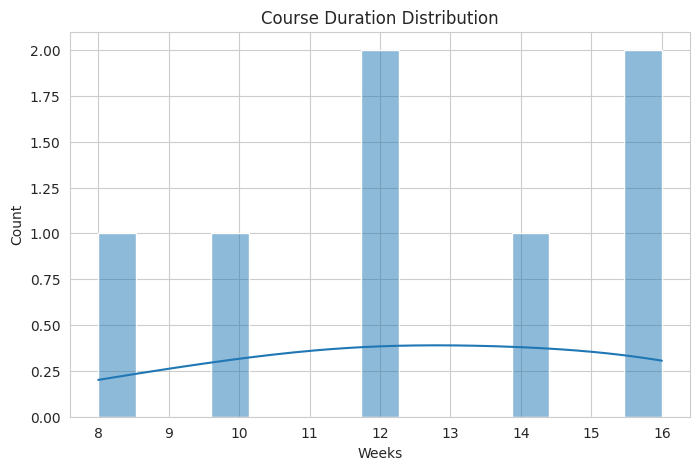

In [253]:
ax = plt.figure(figsize=(8,5))
sns.histplot(
    courses['duration_weeks'],
    bins=15,
    kde=True
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(courses)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Weeks")
plt.ylabel("Count")

plt.title('Course Duration Distribution')
plt.xlabel('Weeks')
plt.show()

Duration by Difficulty

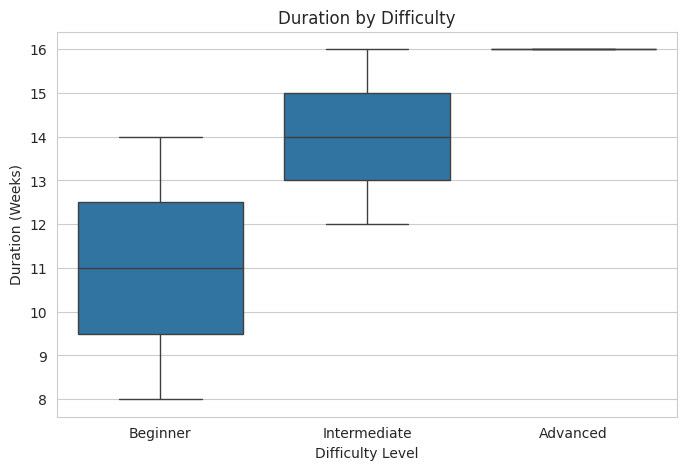

In [254]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=courses,
    x='difficulty_level',
    y='duration_weeks'
)
for p in ax.artists:
    percentage = 100 * p.get_height() / len(courses)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2,
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Difficulty Level")
plt.ylabel("Duration (Weeks)")
plt.title('Duration by Difficulty')
plt.show()

Active vs Inactive Courses

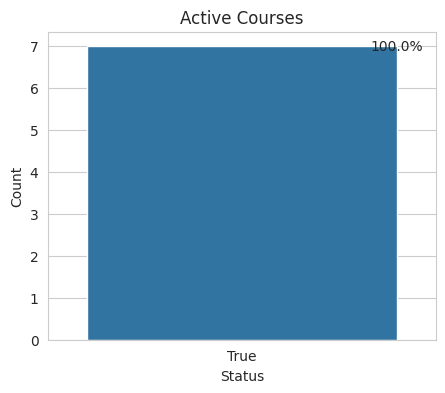

In [255]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=courses,
    x='is_active'
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(courses)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Status")
plt.ylabel("Count")
plt.title('Active Courses')
plt.show()

Average Student Score by Course

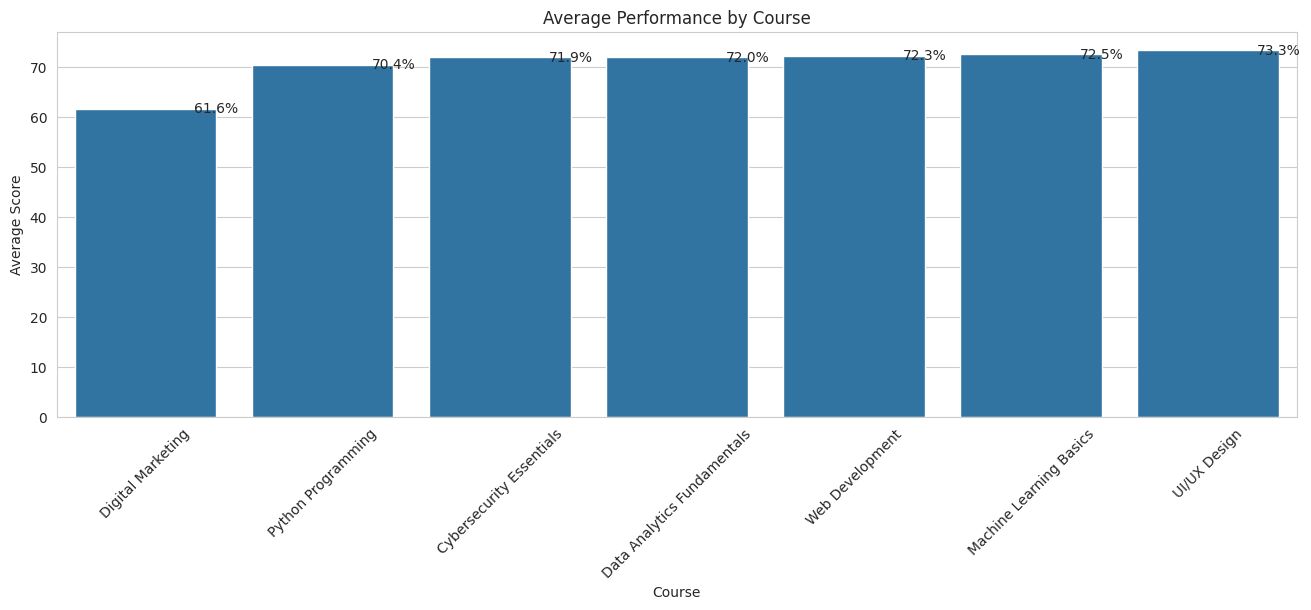

In [256]:
course_perf = (
    concept_performance.groupby('course_id')['score_pct']
            .mean()
            .reset_index()
)

course_perf = course_perf.merge(
    courses,
    on='course_id'
)
plt.figure(figsize=(16,5))

ax = sns.barplot(
    data=course_perf.sort_values('score_pct'),
    x='course_name',
    y='score_pct'
)
for p in ax.patches:
    percentage = p.get_height()
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Course")
plt.ylabel("Average Score")
plt.xticks(rotation=45)
plt.title('Average Performance by Course')
plt.show()

Difficulty vs Student Performance

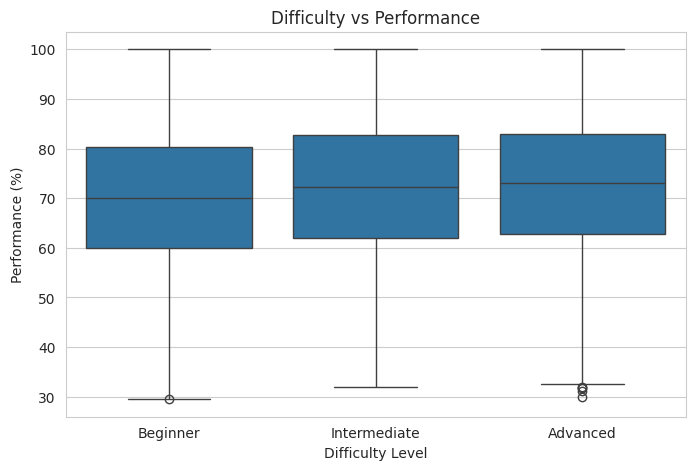

In [257]:
merged = concept_performance.merge(
    courses[['course_id','difficulty_level']],
    on='course_id'
)

plt.figure(figsize=(8,5))

ax = sns.boxplot(
    data=merged,
    x='difficulty_level',
    y='score_pct'
)
for p in ax.artists:
    percentage = 100 * p.get_height() / len(merged)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2,
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Difficulty Level")
plt.ylabel("Performance (%)")
plt.title('Difficulty vs Performance')
plt.show()

there for , we can find out there is some outliers there so we need to remove them


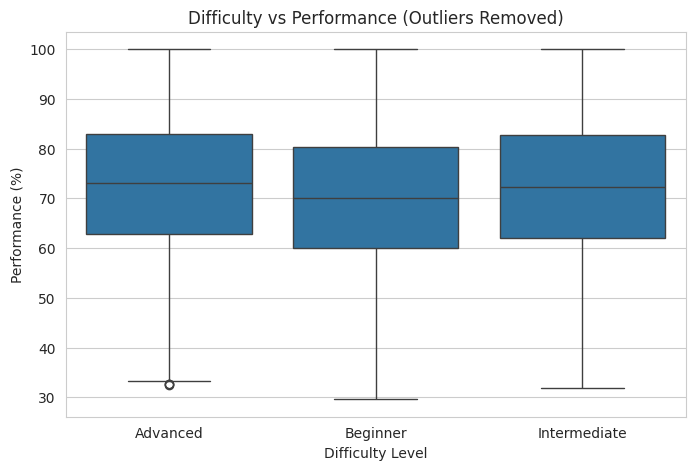

In [258]:
def remove_outliers_iqr(df, column, group_by_column):
    df_cleaned = pd.DataFrame()
    for name, group in df.groupby(group_by_column):
        Q1 = group[column].quantile(0.25)
        Q3 = group[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        filtered_group = group[(group[column] >= lower_bound) & (group[column] <= upper_bound)]
        df_cleaned = pd.concat([df_cleaned, filtered_group])
    return df_cleaned

merged_cleaned = remove_outliers_iqr(merged, 'score_pct', 'difficulty_level')

plt.figure(figsize=(8,5))
ax = sns.boxplot(
    data=merged_cleaned,
    x='difficulty_level',
    y='score_pct'
)
plt.xlabel("Difficulty Level")
plt.ylabel("Performance (%)")
plt.title('Difficulty vs Performance (Outliers Removed)')
plt.show()


Category vs Performance

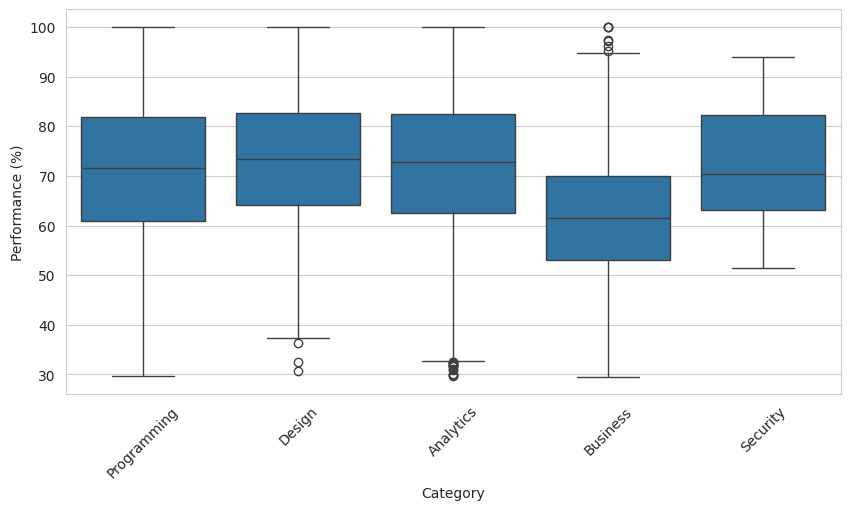

In [259]:
merged = concept_performance.merge(
    courses[['course_id','category']],
    on='course_id'
)

plt.figure(figsize=(10,5))

ax = sns.boxplot(
    data=merged,
    x='category',
    y='score_pct'
)
for p in ax.artists:
    percentage = 100 * p.get_height() / len(merged)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2,
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Category")
plt.ylabel("Performance (%)")

plt.xticks(rotation=45)
plt.show()

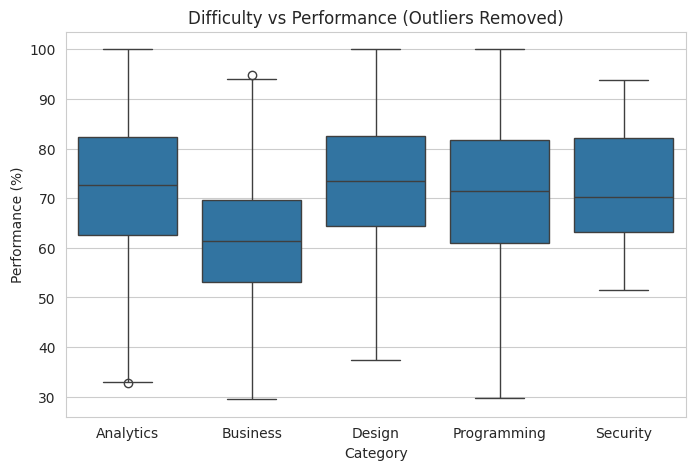

In [260]:
merged_cleaned = remove_outliers_iqr(merged, 'score_pct', 'category')

plt.figure(figsize=(8,5))
ax = sns.boxplot(
    data=merged_cleaned,
    x='category',
    y='score_pct'
)
plt.xlabel("Category")
plt.ylabel("Performance (%)")
plt.title('Difficulty vs Performance (Outliers Removed)')
plt.show()


In [261]:
print(f"Original concept_performance shape: {concept_performance.shape}")
concept_performance = remove_outliers_iqr(concept_performance, 'score_pct', 'course_id')


Original concept_performance shape: (11917, 10)


In [262]:
print(f"Cleaned concept_performance shape: {concept_performance.shape}")
print("Concept Performance DataFrame after outlier removal - Head:")
display(concept_performance.head())

Cleaned concept_performance shape: (11895, 10)
Concept Performance DataFrame after outlier removal - Head:


,record_id,student_id,course_id,assessment_id,question_no,concept_id,concept_name,score_pct,mastery_status,timestamp
72,CP000073,S0004,C001,C001-QZ,1,C001-K02,Descriptive Statistics,84.1,passed,2025-12-26T00:58:46
73,CP000074,S0004,C001,C001-QZ,2,C001-K01,Spreadsheets & Tabular Data,86.1,passed,2025-12-26T00:58:46
74,CP000075,S0004,C001,C001-QZ,3,C001-K05,Joins & Merges,70.5,passed,2025-12-26T00:58:46
75,CP000076,S0004,C001,C001-QZ,4,C001-K06,Data Visualization Basics,84.2,passed,2025-12-26T00:58:46
76,CP000077,S0004,C001,C001-QZ,1,C001-K05,Joins & Merges,64.7,passed,2026-01-09T00:58:46


#EDA engagnement events

In [263]:
print("Engagement Events DataFrame - Head:")
display(engagement_events.head())

print("\nEngagement Events DataFrame - Info:")
engagement_events.info()


Engagement Events DataFrame - Head:


,event_id,student_id,event_type,event_datetime,duration_seconds,device
0,EV000001,S0001,quiz_attempt,2025-01-01T08:00:00,NaN,mobile
1,EV000002,S0001,video_watch,2026-04-15T08:24:37,-120.0,web
2,EV000003,S0001,forum_post,2026-01-25T17:33:56,NaN,web
3,EV000004,S0001,video_watch,2026-04-08T17:16:22,99999.0,web
4,EV000005,S0001,video_watch,2026-05-18T22:50:28,590.0,mobile



Engagement Events DataFrame - Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30866 entries, 0 to 30865
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   event_id          30866 non-null  object 
 1   student_id        30866 non-null  object 
 2   event_type        30866 non-null  object 
 3   event_datetime    30866 non-null  object 
 4   duration_seconds  8817 non-null   float64
 5   device            30866 non-null  object 
dtypes: float64(1), object(5)
memory usage: 1.4+ MB


In [264]:

print("\nEngagement Events DataFrame - Descriptive Statistics:")
display(engagement_events.describe(include='all'))



Engagement Events DataFrame - Descriptive Statistics:


,event_id,student_id,event_type,event_datetime,duration_seconds,device
count,30866,30866,30866,30866,8817.000000,30866
unique,30858,501,5,30832,NaN,2
top,EV007941,S0328,login,2026-05-03T15:29:21,NaN,web
freq,2,95,11052,2,NaN,18559
mean,NaN,NaN,NaN,NaN,615.490643,NaN
std,NaN,NaN,NaN,NaN,1079.115455,NaN
min,NaN,NaN,NaN,NaN,-120.000000,NaN
25%,NaN,NaN,NaN,NaN,461.000000,NaN
50%,NaN,NaN,NaN,NaN,604.000000,NaN
75%,NaN,NaN,NaN,NaN,748.000000,NaN


In [265]:

print("\nEngagement Events DataFrame - Null Values:")
print(engagement_events.isnull().sum())


Engagement Events DataFrame - Null Values:
event_id                0
student_id              0
event_type              0
event_datetime          0
duration_seconds    22049
device                  0
dtype: int64


In [266]:
duplicates = engagement_events[engagement_events['event_id'].duplicated(keep=False)]
print(duplicates.sort_values('event_id'))
engagement_events = engagement_events.drop_duplicates(subset='event_id', keep='first')

       event_id student_id    event_type       event_datetime  \
4737   EV004738      S0073   video_watch  2026-03-23T21:04:17   
30862  EV004738      S0073   video_watch  2026-03-23T21:04:17   
5601   EV005602      S0088  quiz_attempt  2025-12-22T22:12:55   
30859  EV005602      S0088  quiz_attempt  2025-12-22T22:12:55   
7940   EV007941      S0124   video_watch  2026-05-24T16:29:43   
30865  EV007941      S0124   video_watch  2026-05-24T16:29:43   
9953   EV009954      S0158   video_watch  2026-01-24T16:56:09   
30863  EV009954      S0158   video_watch  2026-01-24T16:56:09   
18360  EV018361      S0295         login  2025-12-22T13:21:58   
30861  EV018361      S0295         login  2025-12-22T13:21:58   
19946  EV019947      S0320   video_watch  2026-02-07T02:00:03   
30860  EV019947      S0320   video_watch  2026-02-07T02:00:03   
21205  EV021206      S0340  quiz_attempt  2025-12-21T14:36:42   
30864  EV021206      S0340  quiz_attempt  2025-12-21T14:36:42   
21220  EV021221      S034

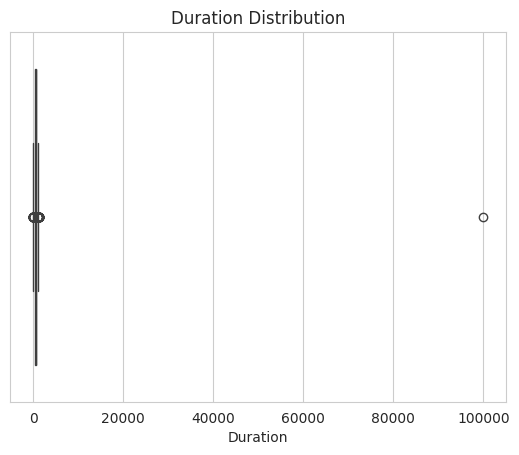

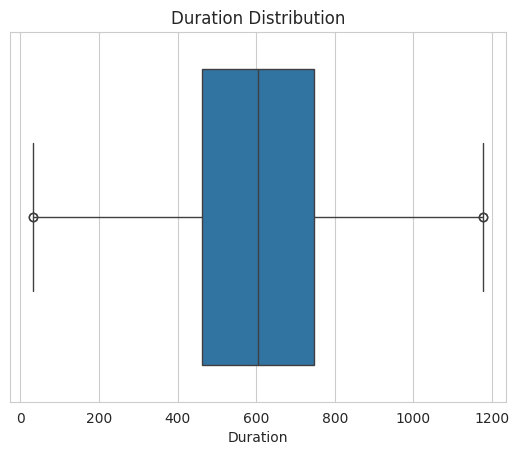

In [267]:
engagement_events_cleaned = engagement_events[engagement_events['duration_seconds'] != 0].copy()
sns.boxplot(x=engagement_events_cleaned['duration_seconds'])
plt.title('Duration Distribution')
plt.xlabel('Duration')
plt.show()
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df
engagement_events = remove_outliers_iqr(engagement_events_cleaned, 'duration_seconds')
sns.boxplot(x=engagement_events['duration_seconds'])
plt.title('Duration Distribution')
plt.xlabel('Duration')
plt.show()

Event Type Distribution

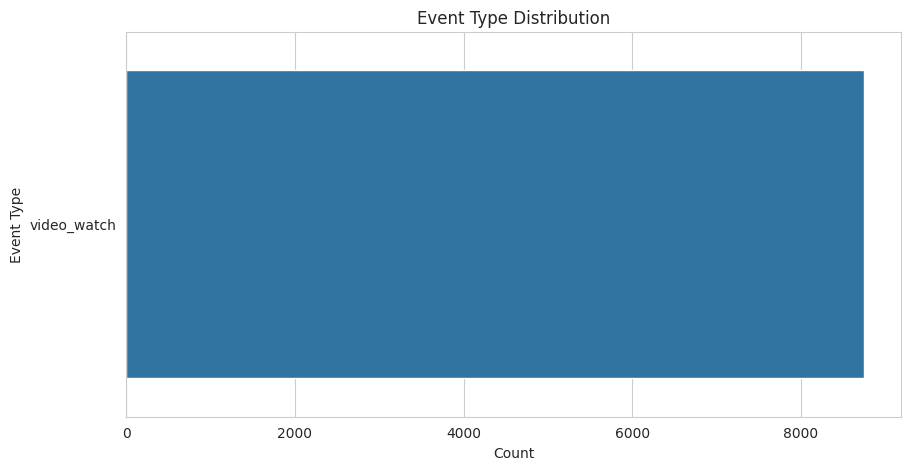

In [268]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=engagement_events,
    y='event_type',
    order=engagement_events['event_type'].value_counts().index
)
plt.xlabel("Count")
plt.ylabel("Event Type")

plt.title("Event Type Distribution")
plt.show()

In [269]:
engagement_events['event_type']=engagement_events['event_type'].str.replace("_"," ")

/tmp/ipykernel_12605/2982685943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  engagement_events['event_type']=engagement_events['event_type'].str.replace("_"," ")


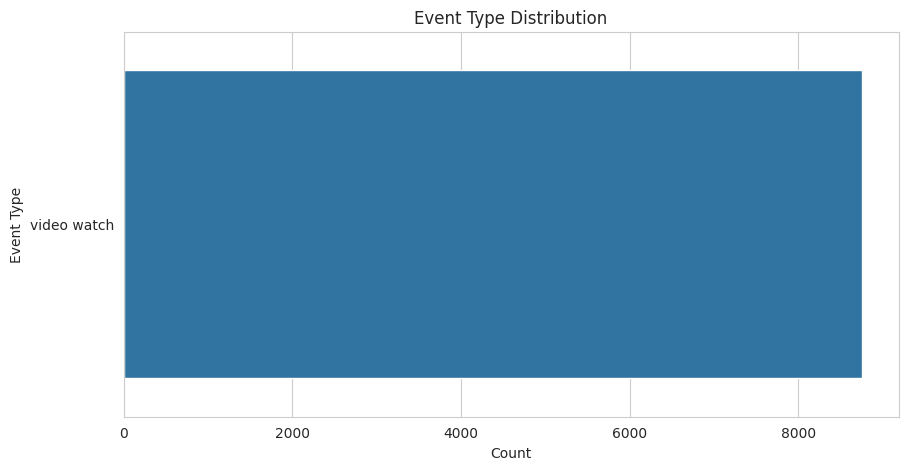

In [270]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=engagement_events,
    y='event_type',
    order=engagement_events['event_type'].value_counts().index
)
plt.xlabel("Count")
plt.ylabel("Event Type")

plt.title("Event Type Distribution")
plt.show()

Device Usage

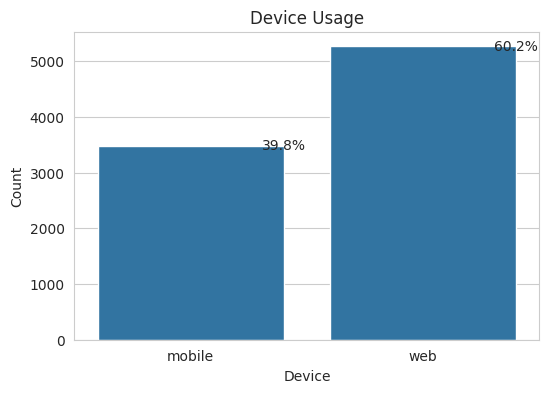

In [271]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=engagement_events,
    x='device'
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(engagement_events)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Device")
plt.ylabel("Count")
plt.title("Device Usage")
plt.show()

Activity Over Time

/tmp/ipykernel_12605/3321027490.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  engagement_events['event_datetime'] = pd.to_datetime(


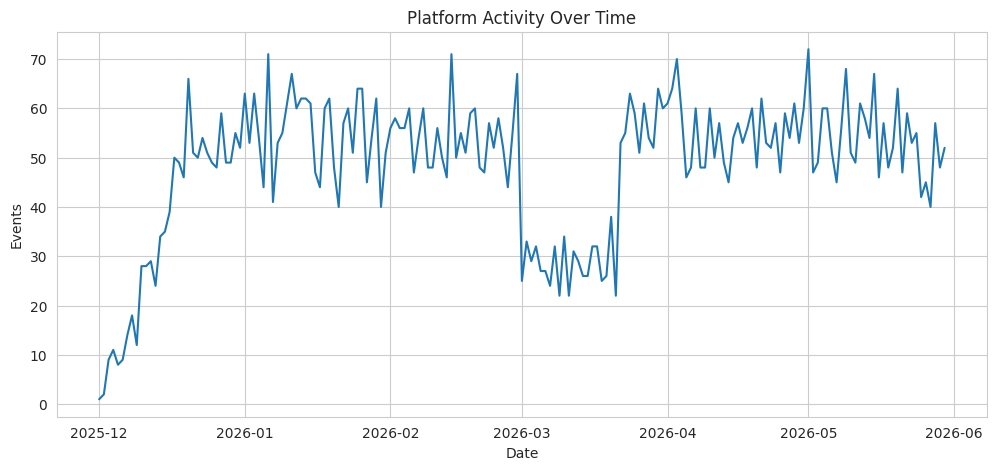

In [272]:
engagement_events['event_datetime'] = pd.to_datetime(
    engagement_events['event_datetime']
)

daily_events = (
    engagement_events.groupby(
        engagement_events['event_datetime'].dt.date
    ).size()
)

plt.figure(figsize=(12,5))

ax = daily_events.plot()
for p in ax.patches:
    percentage = 100 * p.get_height() / len(engagement_events)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Date")
plt.ylabel("Events")
plt.title("Platform Activity Over Time")
plt.show()

In [273]:
last_event_per_type = engagement_events.loc[engagement_events.groupby('event_type')['event_datetime'].idxmax()]
print("Last event per event type:")
display(last_event_per_type)

Last event per event type:


,event_id,student_id,event_type,event_datetime,duration_seconds,device
4882,EV004883,S0076,video watch,2026-05-30 23:53:16,579.0,web


In [274]:
print(f"Original engagement_events shape: {engagement_events.shape}")
engagement_events = engagement_events[engagement_events['event_datetime'] <= '2026-06-01']
engagement_events = engagement_events[engagement_events['event_datetime'] >= '2025-12-01']
print(f"Engagement_events shape after removing events after June 2026 and before Dec 2025: {engagement_events.shape}")


Original engagement_events shape: (8749, 6)
Engagement_events shape after removing events after June 2026 and before Dec 2025: (8749, 6)


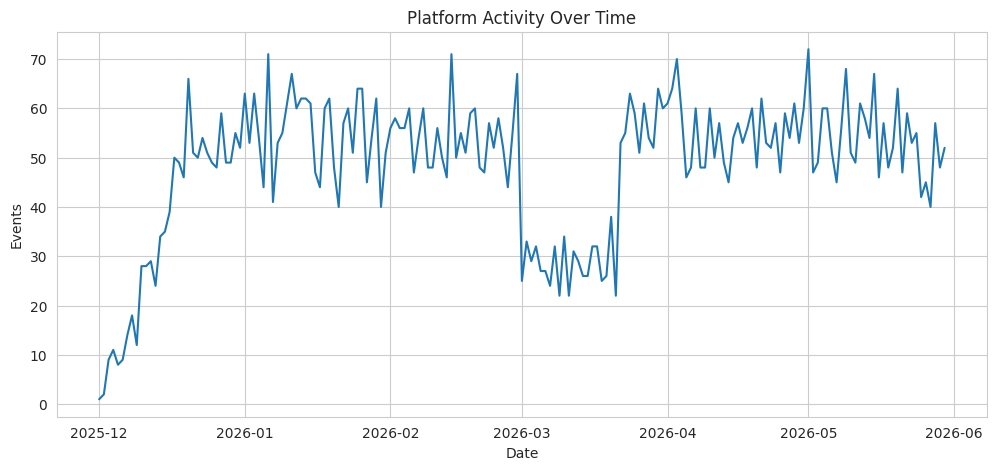

In [275]:
engagement_events['event_datetime'] = pd.to_datetime(
    engagement_events['event_datetime']
)

daily_events = (
    engagement_events.groupby(
        engagement_events['event_datetime'].dt.date
    ).size()
)

plt.figure(figsize=(12,5))

ax = daily_events.plot()
for p in ax.patches:
    percentage = 100 * p.get_height() / len(engagement_events)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Date")
plt.ylabel("Events")
plt.title("Platform Activity Over Time")
plt.show()

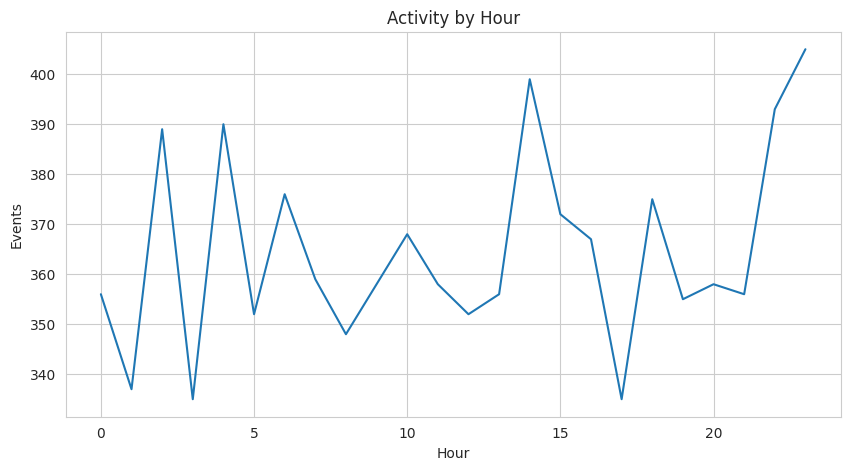

In [276]:
engagement_events['hour'] = (
    engagement_events['event_datetime']
    .dt.hour
)

hourly = (
    engagement_events.groupby('hour')
    .size()
)

plt.figure(figsize=(10,5))

ax = hourly.plot(kind='line')
for p in ax.patches:
    percentage = 100 * p.get_height() / len(engagement_events)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.title("Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Events")
plt.show()

Activity by Day of Week

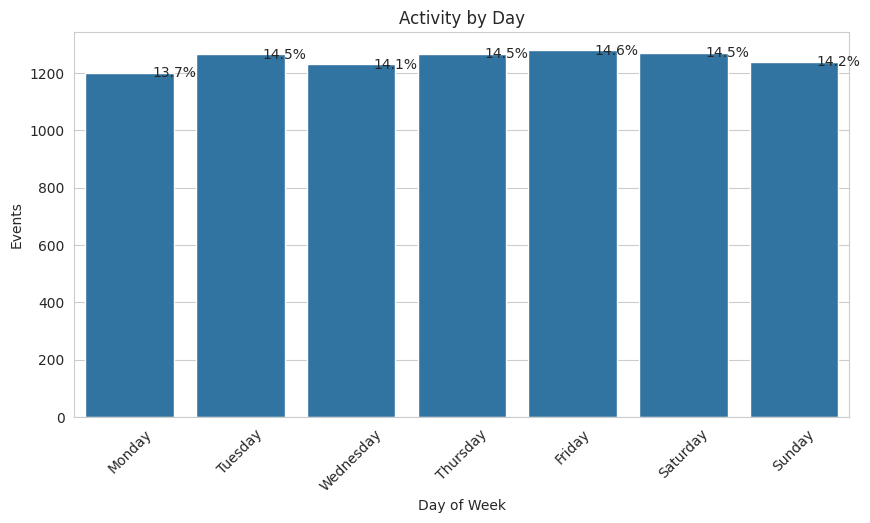

In [277]:
engagement_events['day'] = (
    engagement_events['event_datetime']
    .dt.day_name()
)

day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday',
    'Saturday','Sunday'
]

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=engagement_events,
    x='day',
    order=day_order
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(engagement_events)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Day of Week")
plt.ylabel("Events")

plt.xticks(rotation=45)
plt.title("Activity by Day")
plt.show()

Session Duration Analysis

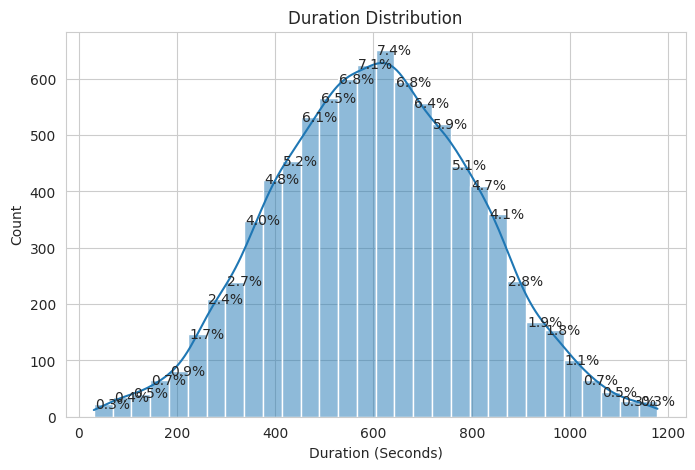

In [278]:
plt.figure(figsize=(8,5))

ax = sns.histplot(
    engagement_events['duration_seconds']
        .dropna(),
    bins=30,
    kde=True
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(engagement_events)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Duration (Seconds)")
plt.ylabel("Count")

plt.title("Duration Distribution")
plt.show()

In [279]:
engagement_events['duration_seconds'] = engagement_events.groupby('event_type')['duration_seconds'].transform(lambda x: x.fillna(x.mean()))
print("Null values in 'duration_seconds' after imputation:")
print(engagement_events['duration_seconds'].isnull().sum())

Null values in 'duration_seconds' after imputation:
0


In [280]:
engagement_events.groupby('event_type')['duration_seconds']\
          .agg(['count','mean','median'])

,count,mean,median
event_type,,,
video watch,8749,603.863184,604.0


Average Duration per Event Type

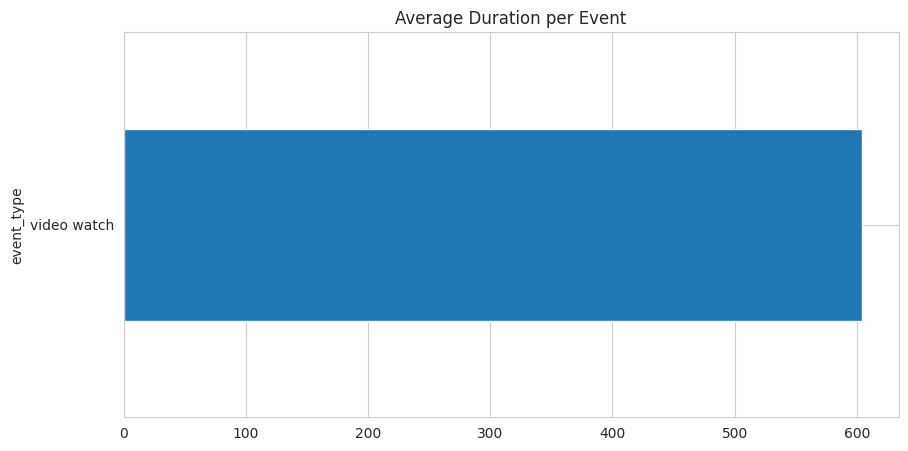

In [281]:
duration_by_event = (
    engagement_events.groupby('event_type')
              ['duration_seconds']
              .mean()
              .sort_values()
)

plt.figure(figsize=(10,5))

duration_by_event.plot(
    kind='barh'
)

plt.title("Average Duration per Event")
plt.show()

Most Active Students

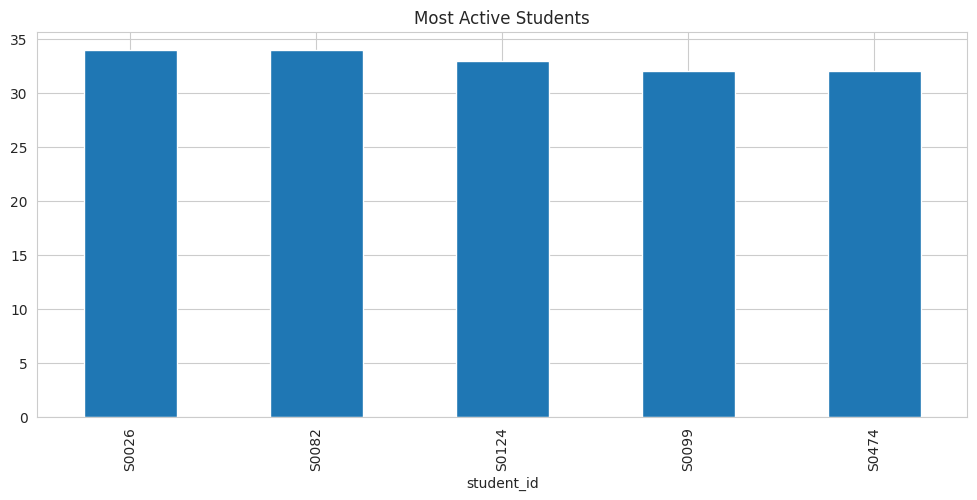

In [283]:
student_events = (
    engagement_events.groupby('student_id')
              .size()
              .sort_values(
                  ascending=False
              ).head()

)

plt.figure(figsize=(12,5))

student_events.plot(
    kind='bar'
)

plt.title("Most Active Students")
plt.show()

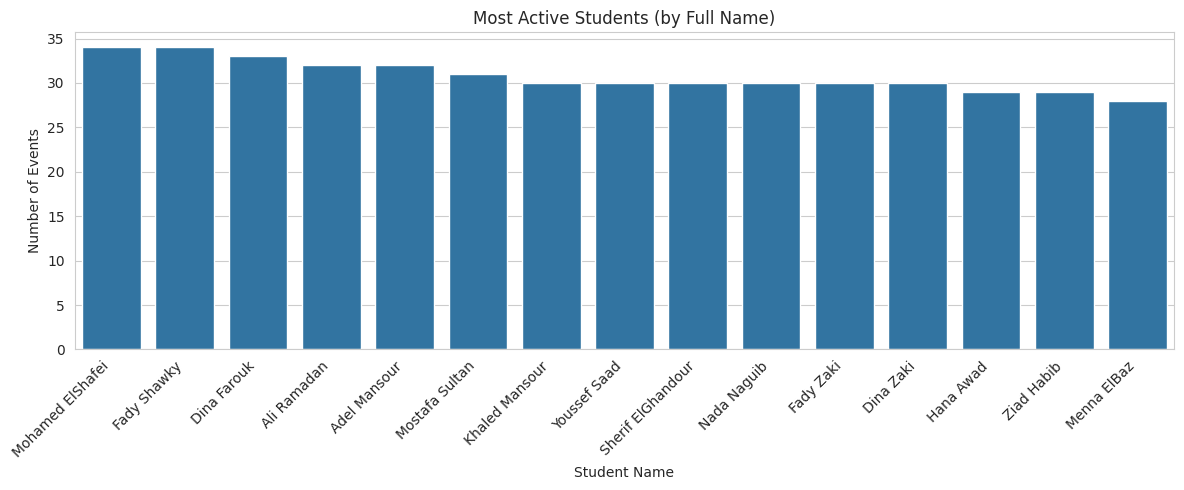

In [284]:
student_events = engagement_events.groupby('student_id').size().sort_values(ascending=False).head(15).reset_index(name='event_count')

# Ensure 'student_id' is unique in students DataFrame before mapping
students_unique = students.drop_duplicates(subset=['student_id'])

student_events = student_events.merge(students_unique[['student_id', 'full_name']], on='student_id', how='left')

plt.figure(figsize=(12, 5))
sns.barplot(x='full_name', y='event_count', data=student_events)
plt.title('Most Active Students (by Full Name)')
plt.xlabel('Student Name')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Student Activity Distribution

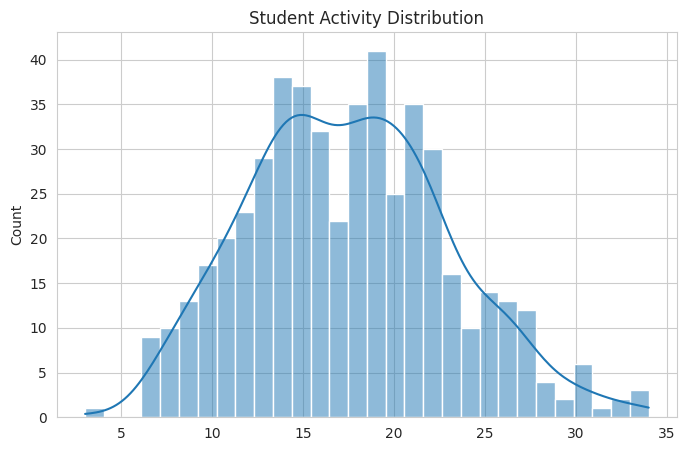

In [285]:
student_activity = (
    engagement_events.groupby('student_id')
              .size()
)

plt.figure(figsize=(8,5))

sns.histplot(
    student_activity,
    bins=30,
    kde=True
)

plt.title("Student Activity Distribution")
plt.show()

#EDA groups

In [286]:
print("Groups DataFrame - Head:")
display(groups.head(12))



Groups DataFrame - Head:


,group_id,group_name,course_id,stated_num_students,session_day,session_time,instructor
0,G01,Group 01 — C001,C001,52,Thursday,16:00,Eng. Khaled Adel
1,G02,Group 02 — C001,C001,56,Thursday,18:00,Dr. Mona Saad
2,G03,Group 03 — C002,C002,67,Sunday,6 PM,Dr. Laila ElBaz
3,G04,Group 04 — C002,C002,65,Saturday,16:00,Eng. Hossam Refaat
4,G05,Group 05 — C003,C003,76,Tuesday,1800,Eng. Khaled Adel
5,G06,Group 06 — C004,C004,56,Saturday,17:00,Dr. Mona Saad
6,G07,Group 07 — C005,C005,70,Wednesday,21:00,Eng. Hossam Refaat
7,G08,Group 08 — C006,C006,60,Saturday,17:00,Dr. Laila ElBaz
8,G09,Group 09 — C006,C006,51,Thursday,19:00,Dr. Mona Saad
9,G10,Group 10 — C007,C007,31,Tuesday,18:00,Eng. Khaled Adel


In [287]:
groups.dropna(inplace=True)

There is tested group deleted so we have to drop it

In [288]:
print("\nGroups DataFrame - Info:")
groups.info()



Groups DataFrame - Info:
<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, 0 to 11
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   group_id             11 non-null     object
 1   group_name           11 non-null     object
 2   course_id            11 non-null     object
 3   stated_num_students  11 non-null     int64 
 4   session_day          11 non-null     object
 5   session_time         11 non-null     object
 6   instructor           11 non-null     object
dtypes: int64(1), object(6)
memory usage: 704.0+ bytes


In [289]:

print("\nGroups DataFrame - Descriptive Statistics:")
display(groups.describe(include='all'))



Groups DataFrame - Descriptive Statistics:


,group_id,group_name,course_id,stated_num_students,session_day,session_time,instructor
count,11,11,11,11.000000,11,11,11
unique,10,10,7,NaN,5,7,4
top,G01,Group 01 — C001,C001,NaN,Thursday,16:00,Eng. Khaled Adel
freq,2,2,3,NaN,4,3,4
mean,NaN,NaN,NaN,57.818182,NaN,NaN,NaN
std,NaN,NaN,NaN,12.081541,NaN,NaN,NaN
min,NaN,NaN,NaN,31.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,52.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,56.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,66.000000,NaN,NaN,NaN


In [290]:

print("\nGroups DataFrame - Null Values:")
print(groups.isnull().sum())


Groups DataFrame - Null Values:
group_id               0
group_name             0
course_id              0
stated_num_students    0
session_day            0
session_time           0
instructor             0
dtype: int64


In [291]:
duplicates = groups[groups['group_id'].duplicated(keep=False)]
print(duplicates.sort_values('group_id'))
groups = groups.drop_duplicates(subset='group_id', keep='first')

   group_id       group_name course_id  stated_num_students session_day  \
0       G01  Group 01 — C001      C001                   52    Thursday   
11      G01  Group 01 — C001      C001                   52    Thursday   

   session_time        instructor  
0         16:00  Eng. Khaled Adel  
11        16:00  Eng. Khaled Adel  


Group Size Reality Check

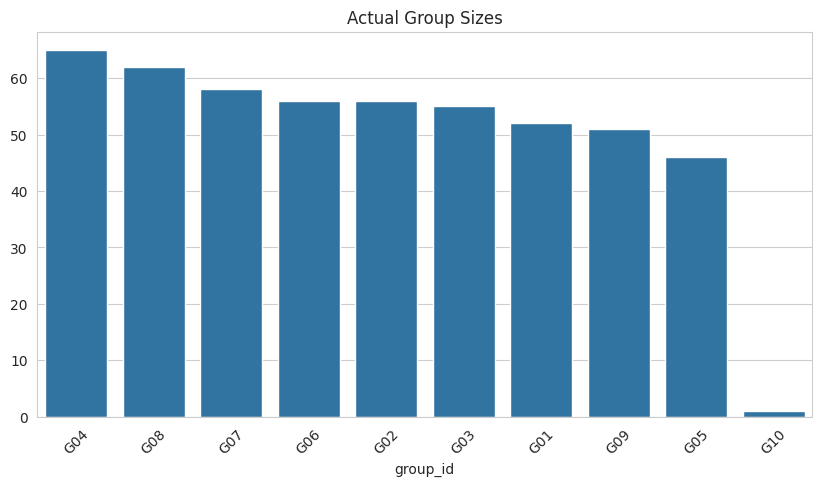

In [292]:
group_sizes = students['group_id'].value_counts()

plt.figure(figsize=(10,5))
sns.barplot(x=group_sizes.index, y=group_sizes.values)

plt.title("Actual Group Sizes")
plt.xticks(rotation=45)
plt.show()

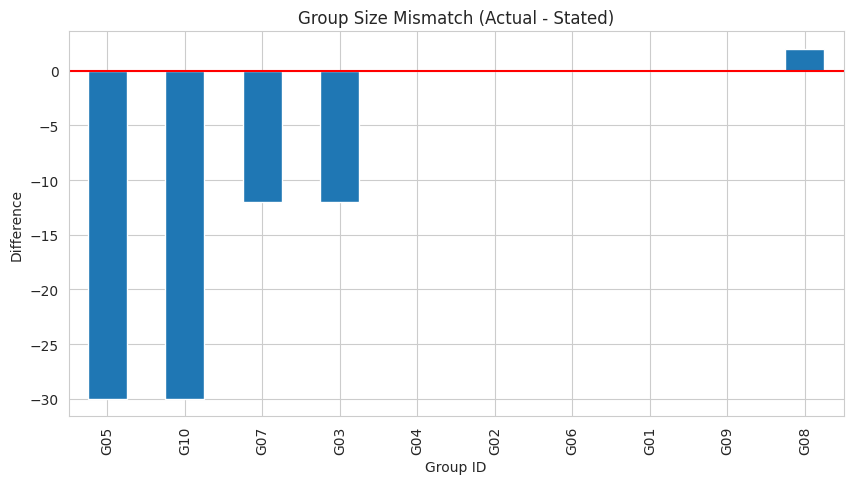

In [293]:
actual = students.groupby('group_id').size()

comparison = groups.set_index('group_id')[['stated_num_students']].copy()
comparison['actual'] = actual
comparison['diff'] = comparison['actual'] - comparison['stated_num_students']
comparison['diff'].sort_values().plot(kind='bar', figsize=(10,5))
plt.xlabel("Group ID")
plt.ylabel("Difference")
plt.title("Group Size Mismatch (Actual - Stated)")
plt.axhline(0, color='red')
plt.show()

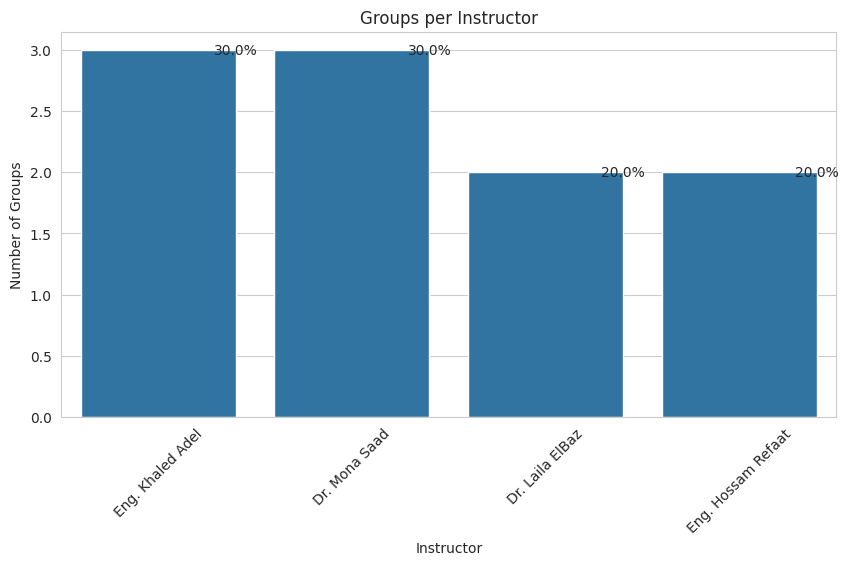

In [294]:
instructor_load = groups['instructor'].value_counts()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=instructor_load.index, y=instructor_load.values)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(groups)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Instructor")
plt.ylabel("Number of Groups")
plt.title("Groups per Instructor")
plt.xticks(rotation=45)
plt.show()

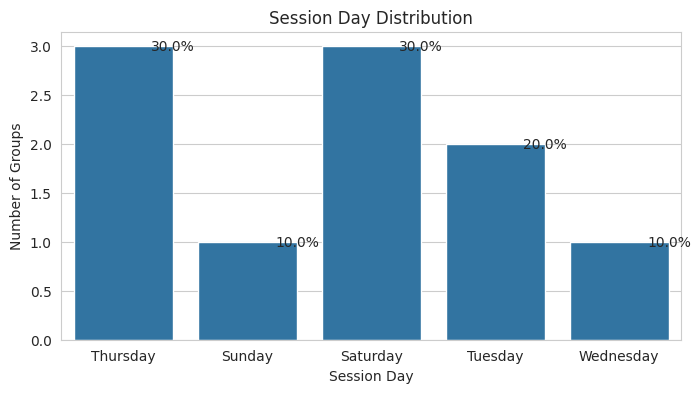

In [295]:
plt.figure(figsize=(8,4))
ax = sns.countplot(data=groups, x='session_day')
for p in ax.patches:
    percentage = 100 * p.get_height() / len(groups)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Session Day")
plt.ylabel("Number of Groups")
plt.title("Session Day Distribution")
plt.show()

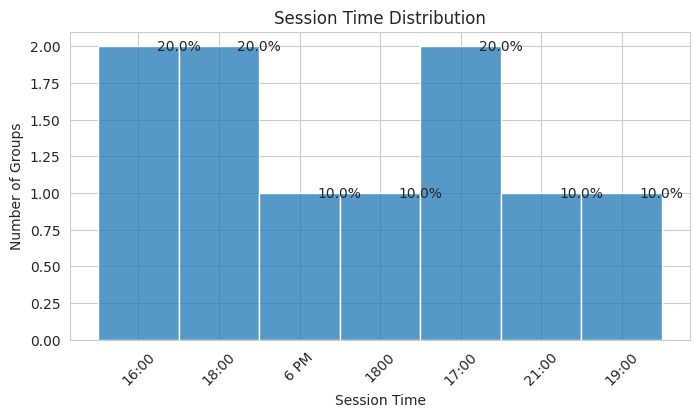

In [296]:
plt.figure(figsize=(8,4))
ax = sns.histplot(groups['session_time'].astype(str))
for p in ax.patches:
    percentage = 100 * p.get_height() / len(groups)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Session Time")
plt.ylabel("Number of Groups")
plt.title("Session Time Distribution")
plt.xticks(rotation=45)
plt.show()

In [297]:
groups['session_time'] = groups['session_time'].replace("6 PM","18:00")
groups['session_time'] = groups['session_time'].replace("1800","18:00")


/tmp/ipykernel_12605/3481078022.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  groups['session_time'] = groups['session_time'].replace("6 PM","18:00")
/tmp/ipykernel_12605/3481078022.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  groups['session_time'] = groups['session_time'].replace("1800","18:00")


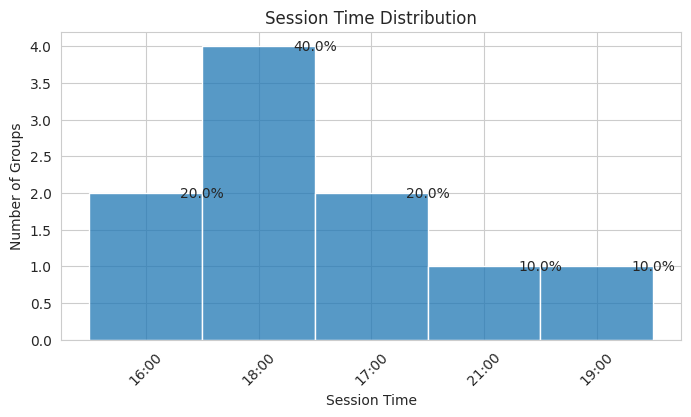

In [298]:
plt.figure(figsize=(8,4))
ax = sns.histplot(groups['session_time'].astype(str))
for p in ax.patches:
    percentage = 100 * p.get_height() / len(groups)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Session Time")
plt.ylabel("Number of Groups")
plt.title("Session Time Distribution")
plt.xticks(rotation=45)
plt.show()

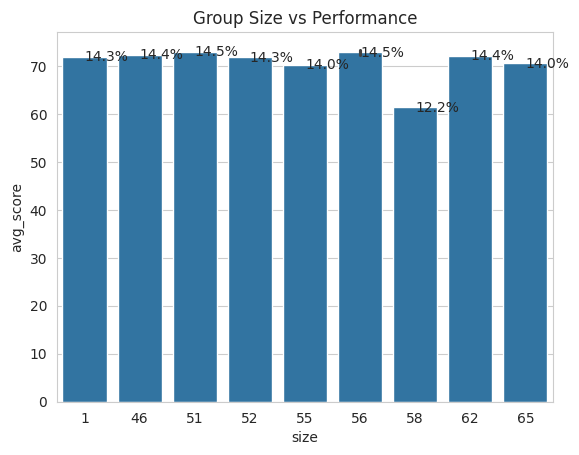

In [299]:
merged = students.merge(groups, on='group_id')
group_perf = merged.merge(
    concept_performance.groupby('student_id')['score_pct'].mean().reset_index(),
    on='student_id'
)

summary = group_perf.groupby('group_id').agg(
    avg_score=('score_pct','mean'),
    size=('student_id','count')
)
ax = sns.barplot(
    data=summary,
    x='size',
    y='avg_score'
)
for p in ax.patches:
    percentage = 100 * p.get_height() / len(group_perf)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')

plt.title("Group Size vs Performance")
plt.show()

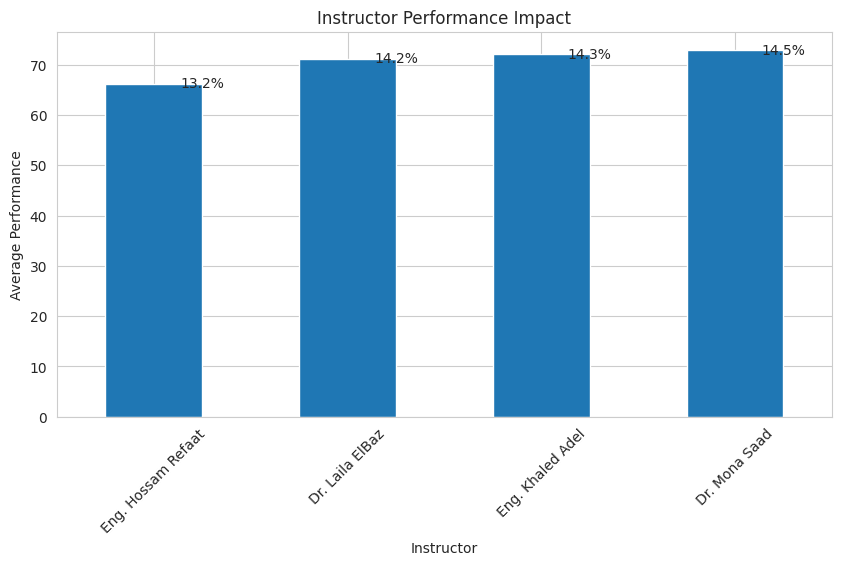

In [300]:
instructor_perf = group_perf.groupby('instructor')['score_pct'].mean()

ax = instructor_perf.sort_values().plot(kind='bar', figsize=(10,5))
for p in ax.patches:
    percentage = 100 * p.get_height() / len(group_perf)
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width(),
                 p.get_height()),
                ha='center',
                va='center')
plt.xlabel("Instructor")
plt.ylabel("Average Performance")
plt.xticks(rotation=45)
plt.title("Instructor Performance Impact")
plt.show()

In [306]:
# saving the cleaned files
import shutil
import os
cleaned_data_dir = "cleaned data"
if os.path.exists(cleaned_data_dir):
    shutil.rmtree(cleaned_data_dir)
os.makedirs(cleaned_data_dir)

In [307]:
students.to_csv(f"{cleaned_data_dir}/students.csv", index=False)
groups.to_csv(f"{cleaned_data_dir}/groups.csv", index=False)
engagement_events.to_csv(f"{cleaned_data_dir}/engagement_events.csv", index=False)
concept_performance.to_csv(f"{cleaned_data_dir}/concept_performance.csv", index=False)
assignment_submission.to_csv(f"{cleaned_data_dir}/assignment_submission.csv", index=False)
attendance.to_csv(f"{cleaned_data_dir}/attendance.csv", index=False)
grades.to_csv(f"{cleaned_data_dir}/grades.csv", index=False)
courses.to_csv(f"{cleaned_data_dir}/courses.csv", index=False)


In [308]:
import zipfile
import os

output_zip_file = '/content/cleaned_data.zip'
cleaned_data_dir = '/content/cleaned data'

with zipfile.ZipFile(output_zip_file, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(cleaned_data_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, cleaned_data_dir)
            zipf.write(file_path, arcname)

print(f"Folder '{cleaned_data_dir}' successfully zipped to '{output_zip_file}'")

Folder '/content/cleaned data' successfully zipped to '/content/cleaned_data.zip'
